In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 1. Data Preparation

This section prepares the UQA dataset for Urdu Question Generation.

We will:
- load the UQA dataset,
- inspect its structure,
- extract answer-containing sentences,
- mark answer spans with `<ans>` and `</ans>`,
- apply length filtering,
- save train/validation TSV files,
- and prepare Wiki-UQA for out-of-domain evaluation.

In [ ]:
!git clone https://github.com/RazaSherazi09/urdu-qgen-seq2seq.git /kaggle/working/urdu-qgen-seq2seq

In [ ]:
%cd /kaggle/working/urdu-qgen-seq2seq

!pwd
!ls

### Project setup

The repository has been cloned into Kaggle's working directory.
We now install the same dependencies used by the project and make
the repository importable as a Python package.

In [ ]:
!pip install -q -r requirements.txt

In [ ]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path("/kaggle/working/urdu-qgen-seq2seq").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)
print("Working directory:", Path.cwd())

In [ ]:
from src.data.prepare_data import (
    prepare_uqa_data,
    prepare_wiki_uqa_data,
)

print("src imports successfully.")

### Project verification

Before loading the dataset, we verify that Kaggle sees the expected
project files and that the `src` package can be imported correctly.

In [ ]:
!find . -maxdepth 2 -type f | sort

In [ ]:
from datasets import load_dataset
import csv
import matplotlib.pyplot as plt

from configs.config import (
    DATASET_NAME,
    DATA_DIR,
    TRAIN_FILE,
    VALID_FILE,
)

print("DATASET_NAME:", DATASET_NAME)
print("DATA_DIR:", DATA_DIR)
print("TRAIN_FILE:", TRAIN_FILE)
print("VALID_FILE:", VALID_FILE)

## Step 1: Load the UQA dataset

We now download the UQA dataset from Hugging Face using the dataset
name defined in `configs/config.py`.

In [ ]:
dataset = load_dataset(DATASET_NAME)

print(dataset)

print(f"\nTrain rows: {len(dataset['train'])}")
print(f"Validation rows: {len(dataset['validation'])}")

## Step 2: Inspect the dataset structure

We inspect the column names, data types, and one complete example.
This confirms the exact answer format before preprocessing.

In [ ]:
print("Dataset columns:")
print(dataset["train"].column_names)

print("\nDataset features:")
print(dataset["train"].features)

print("\nFirst training example:")


row = dataset["train"][0]

for key, value in row.items():
    print(f"\n{key}:")
    print(value)

## Step 3: Make preprocessing compatible with the UQA schema

The downloaded UQA dataset stores the answer as `answer` and its
character offset as `answer_start`.

The preprocessing function also supports the nested SQuAD-style
`answers` format, so it can work with either schema.

In [ ]:
prepare_file = PROJECT_ROOT / "src" / "data" / "prepare_data.py"


text = prepare_file.read_text(encoding="utf-8")

old_block = '''        answers = row.get("answers", {})
        texts = answers.get("text", [])
        starts = answers.get("answer_start", [])
        if not texts or not starts:
            continue
        stats["answerable_rows"] += 1

        # Use the first answer
        answer_text = texts[0]
        answer_start = starts[0]
'''

new_block = '''        # Support both:
        # 1. Current UQA flat format:
        #       {"answer": "...", "answer_start": 123}
        #
        # 2. SQuAD-style nested format:
        #       {"answers": {"text": [...], "answer_start": [...]}}

        if "answer" in row and "answer_start" in row:
            answer_text = row["answer"]
            answer_start = row["answer_start"]

            if not answer_text or answer_start is None:
                continue

        elif "answers" in row:
            answers = row.get("answers", {})

            texts = answers.get("text", [])
            starts = answers.get("answer_start", [])

            if not texts or not starts:
                continue

            answer_text = texts[0]
            answer_start = starts[0]

        else:
            continue

        stats["answerable_rows"] += 1
'''

if old_block not in text:
    raise RuntimeError(
        "Expected answer-handling block was not found in prepare_data.py."
    )

text = text.replace(old_block, new_block)

prepare_file.write_text(text, encoding="utf-8")

print("prepare_data.py updated successfully.")

In [ ]:
text = prepare_file.read_text(encoding="utf-8")

start = text.find("# Support both:")
end = text.find("# ── Step 2:", start)

print(text[start:end])

### Reload the modified preprocessing module

Python may already have the old version of `prepare_data.py` loaded.
We therefore reload the module before running preprocessing.

In [ ]:
import importlib
import src.data.prepare_data as prepare_module

importlib.reload(prepare_module)

prepare_uqa_data = prepare_module.prepare_uqa_data
prepare_wiki_uqa_data = prepare_module.prepare_wiki_uqa_data

print("prepare_data module reloaded successfully.")

In [ ]:
row = dataset["train"][0]

print("Answer:", row["answer"])
print("Answer start:", row["answer_start"])

context = row["context"]
answer = row["answer"]
answer_start = row["answer_start"]

extracted = context[
    answer_start:
    answer_start + len(answer)
]

print("Extracted:", extracted)
print("Match:", extracted == answer)

### Sentence-level answer extraction

We now verify that the answer offset falls inside the correct
sentence. This sentence will become the model's focused source input.

In [ ]:
from src.data.prepare_data import split_into_sentences

sentences = split_into_sentences(context)

print(f"Number of sentences: {len(sentences)}")

for start, end, sentence in sentences:

    if start <= answer_start < end:

        print("\nAnswer-containing sentence:")
        print(sentence)

        print("\nSentence start:", start)
        print("Sentence end:", end)

        break

## Step 6: Run UQA preprocessing

This function performs answerable-example filtering, sentence extraction,
offset verification, `<ans>` marker insertion, length filtering, and
writes the final training and validation TSV files.

In [ ]:
train_stats, valid_stats = prepare_uqa_data()


In [ ]:
wiki_stats = prepare_wiki_uqa_data()

### Verify generated files

The outputs of Notebook 1 are the inputs for Notebook 2.
We therefore verify that the training and validation TSV files
were actually created and contain data.

In [ ]:
print("Train file exists:", Path(TRAIN_FILE).exists())
print("Valid file exists:", Path(VALID_FILE).exists())

print("\nTrain file:", TRAIN_FILE)
print("Valid file:", VALID_FILE)

if Path(TRAIN_FILE).exists():
    print(
        "Train file size:",
        Path(TRAIN_FILE).stat().st_size,
        "bytes"
    )

if Path(VALID_FILE).exists():
    print(
        "Valid file size:",
        Path(VALID_FILE).stat().st_size,
        "bytes"
    )

In [ ]:
print("\nFirst 3 training pairs:")

with open(
    TRAIN_FILE,
    "r",
    encoding="utf-8"
) as f:

    for i in range(3):

        line = f.readline().strip()

        if line:
            print(f"{i + 1}: {line}")

### Final data sanity check

We verify the TSV header and confirm that the first actual data row
contains a real Urdu source and target rather than the literal strings
`source` and `target`.

In [ ]:
with open(
    TRAIN_FILE,
    "r",
    encoding="utf-8"
) as f:

    lines = [
        next(f).rstrip("\n")
        for _ in range(3)
    ]

print("First three raw lines:\n")

for i, line in enumerate(lines, 1):
    print(f"{i}: {line}")

In [ ]:
print("=" * 70)
print("NOTEBOOK 1 — DATA PREPARATION COMPLETE")
print("=" * 70)

print("\nUQA:")
print("  Training final pairs:", train_stats.get("final_pairs"))
print("  Validation final pairs:", valid_stats.get("final_pairs"))

print("\nWiki-UQA:")
print("  Final pairs:", wiki_stats.get("final_pairs", "N/A"))

print("\nFiles:")
print("  train.tsv:", Path(TRAIN_FILE).exists())
print("  valid.tsv:", Path(VALID_FILE).exists())

print("\nNotebook 1 completed.")

# 2. SentencePiece Tokenizer

This section trains a SentencePiece tokenizer for the Urdu question-generation
dataset. Both source contexts and target questions are used to build the corpus.

The answer markers `<ans>` and `</ans>` are kept as dedicated tokens so the
model can explicitly recognize the answer span during training.

In [ ]:
from pathlib import Path
import csv
import sentencepiece as spm

PROJECT_ROOT = Path(
    "/kaggle/working/urdu-qgen-seq2seq"
).resolve()

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TOKENIZER_DIR = PROJECT_ROOT / "tokenizer"

TRAIN_FILE = DATA_DIR / "train.tsv"
VALID_FILE = DATA_DIR / "valid.tsv"

TOKENIZER_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Train file:", TRAIN_FILE)
print("Valid file:", VALID_FILE)
print("Tokenizer directory:", TOKENIZER_DIR)

In [ ]:
def load_pairs(path):

    pairs = []

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:

        reader = csv.reader(
            f,
            delimiter="\t"
        )

        for row in reader:

            if len(row) < 2:
                continue

            src = row[0].strip()
            tgt = row[1].strip()

            if not src or not tgt:
                continue

            # Skip TSV header
            if (
                src.lower() == "source"
                and tgt.lower() == "target"
            ):
                continue

            pairs.append(
                (src, tgt)
            )

    return pairs


train_pairs = load_pairs(
    TRAIN_FILE
)

valid_pairs = load_pairs(
    VALID_FILE
)

print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(valid_pairs))

### Verify the loaded data

The TSV header is excluded during loading, so only genuine Urdu
source-target pairs are passed to SentencePiece training.

In [ ]:
print("=" * 80)
print("FIRST TRAINING EXAMPLES")
print("=" * 80)

for i in range(3):

    src, tgt = train_pairs[i]

    print("\n" + "-" * 80)

    print("SOURCE:")
    print(src)

    print("\nTARGET:")
    print(tgt)

In [ ]:
ANS_OPEN = "<ans>"
ANS_CLOSE = "</ans>"

marker_open_count = sum(
    ANS_OPEN in src
    for src, _ in train_pairs
)

marker_close_count = sum(
    ANS_CLOSE in src
    for src, _ in train_pairs
)

print("Training examples:", len(train_pairs))

print(
    f"{ANS_OPEN} occurrences:",
    marker_open_count
)

print(
    f"{ANS_CLOSE} occurrences:",
    marker_close_count
)

### Build the tokenizer corpus

We combine every training source and target into one text corpus.
This allows SentencePiece to learn Urdu subword units used by both
the context and question sides of the task.

In [ ]:
CORPUS_FILE = TOKENIZER_DIR / "sp_corpus.txt"

with open(
    CORPUS_FILE,
    "w",
    encoding="utf-8"
) as f:

    for src, tgt in train_pairs:

        f.write(src + "\n")
        f.write(tgt + "\n")

print("Corpus created:")
print(CORPUS_FILE)

print(
    "Corpus size:",
    CORPUS_FILE.stat().st_size,
    "bytes"
)

## Step 2: Train SentencePiece

We use an 8,000-token unigram vocabulary with full Unicode coverage.
The answer markers remain dedicated user-defined symbols.


In [ ]:
SP_PREFIX = TOKENIZER_DIR / "ur_sp"

VOCAB_SIZE = 8000

spm.SentencePieceTrainer.train(
    input=str(CORPUS_FILE),

    model_prefix=str(SP_PREFIX),

    vocab_size=VOCAB_SIZE,

    model_type="unigram",

    character_coverage=1.0,

    user_defined_symbols=[
        ANS_OPEN,
        ANS_CLOSE
    ],

    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3
)

print("SentencePiece training completed.")

In [ ]:
SP_MODEL = TOKENIZER_DIR / "ur_sp.model"
SP_VOCAB = TOKENIZER_DIR / "ur_sp.vocab"

print("Tokenizer model exists:", SP_MODEL.exists())
print("Tokenizer vocab exists:", SP_VOCAB.exists())

if SP_MODEL.exists():
    print(
        "Model size:",
        SP_MODEL.stat().st_size,
        "bytes"
    )

if SP_VOCAB.exists():
    print(
        "Vocab size:",
        SP_VOCAB.stat().st_size,
        "bytes"
    )

### Load and inspect the trained tokenizer

We now load the generated SentencePiece model and verify its vocabulary
size and special-token IDs before using it for model training.

In [ ]:
sp = spm.SentencePieceProcessor()

sp.load(
    str(SP_MODEL)
)

print("Vocabulary size:", sp.get_piece_size())

print("PAD ID:", sp.pad_id())
print("UNK ID:", sp.unk_id())
print("BOS ID:", sp.bos_id())
print("EOS ID:", sp.eos_id())

In [ ]:
print("=" * 80)
print("ANSWER MARKER TOKENIZATION")
print("=" * 80)

marker_ids = sp.encode(
    f"{ANS_OPEN} فرانس {ANS_CLOSE}",
    out_type=int

)

marker_pieces = sp.encode(
    f"{ANS_OPEN} فرانس {ANS_CLOSE}",
    out_type=str
)

print("IDs:")
print(marker_ids)

print("\nPieces:")
print(marker_pieces)

### Tokenization sanity check

We inspect a real Urdu source containing an answer marker and verify
that the tokenizer can encode and decode it without losing information.

In [ ]:
sample_source, sample_target = train_pairs[0]

source_ids = sp.encode(
    sample_source,
    out_type=int
)

source_pieces = sp.encode(
    sample_source,
    out_type=str
)

print("SOURCE:")
print(sample_source)

print("\nTOKEN IDS:")
print(source_ids[:50])

print("\nTOKEN PIECES:")
print(source_pieces[:50])

print("\nNumber of tokens:", len(source_ids))

In [ ]:
decoded_source = sp.decode(
    source_ids
)

print("Original:")
print(sample_source)

print("\nDecoded:")
print(decoded_source)

print(
    "\nExact round-trip:",
    decoded_source == sample_source
)

### Target question verification

Finally, we verify that target questions are tokenized correctly.
The target sequence will later receive BOS and EOS tokens during
seq2seq training.

In [ ]:
target_ids = sp.encode(
    sample_target,
    out_type=int
)

target_pieces = sp.encode(
    sample_target,
    out_type=str
)

print("TARGET:")
print(sample_target)

print("\nTARGET IDS:")
print(target_ids)

print("\nTARGET PIECES:")
print(target_pieces)

print(
    "\nDecoded target:"
)

print(
    sp.decode(target_ids)
)

print(
    "\nTarget round-trip:",
    sp.decode(target_ids) == sample_target
)

In [ ]:
target_with_specials = [
    sp.bos_id()
] + target_ids + [
    sp.eos_id()
]

print("Target with BOS/EOS:")
print(target_with_specials)

print("\nBOS:", target_with_specials[0])
print("EOS:", target_with_specials[-1])
print("Target length:", len(target_with_specials))

## Tokenizer summary

The tokenizer is now ready for Notebook 3.
We verify the final vocabulary, corpus, model, vocabulary file, and data counts.

In [ ]:
print("=" * 80)
print("NOTEBOOK 2 — TOKENIZER SUMMARY")
print("=" * 80)

print()

print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(valid_pairs))

print(
    "Vocabulary size:",
    sp.get_piece_size()
)

print(
    "Tokenizer model exists:",
    SP_MODEL.exists()
)

print(
    "Tokenizer vocab exists:",
    SP_VOCAB.exists()
)

print(
    "Corpus exists:",
    CORPUS_FILE.exists()
)

print(
    "PAD:",
    sp.pad_id()
)

print(
    "UNK:",
    sp.unk_id()
)

print(
    "BOS:",
    sp.bos_id()
)

print(
    "EOS:",
    sp.eos_id()
)

print("\nNotebook 2 completed successfully.")

## Notebook 2 Complete

The SentencePiece tokenizer has been trained and verified successfully.

Outputs:
- `tokenizer/ur_sp.model`
- `tokenizer/ur_sp.vocab`
- `tokenizer/sp_corpus.txt`

The tokenizer uses an 8,000-token vocabulary and preserves the
`<ans>` and `</ans>` answer markers.

# Notebook 3 — Full Training: Experiment 2

This notebook trains the Urdu Question Generation model using the
prepared UQA dataset and the SentencePiece tokenizer.

Experiment 2 changes compared with Experiment 1:

- Learning rate: 3e-4
- Teacher forcing ratio: 0.8
- Batch size: 64
- Gradient clipping: 1.0
- Maximum epochs: 12

The architecture remains unchanged:

BiLSTM Encoder
→ Bahdanau Attention
→ LSTM Decoder
→ Seq2Seq Question Generator

The best model is selected using validation loss.

Training checkpoints and metrics are uploaded to Hugging Face
after every epoch so that training can be resumed if the Kaggle
session is interrupted.

In [1]:
!pip uninstall -y huggingface_hub
!pip install -q --no-cache-dir "huggingface_hub==0.35.3"

Found existing installation: huggingface-hub 0.35.3
Uninstalling huggingface-hub-0.35.3:
  Successfully uninstalled huggingface-hub-0.35.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 15.3 MB/s eta 0:00:00a 0:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.35.3 which is incompatible.


In [2]:
import huggingface_hub

print("huggingface_hub version:", huggingface_hub.__version__)

from huggingface_hub import HfApi, login

print("Hugging Face Hub imports successfully.")

huggingface_hub version: 0.35.3
Hugging Face Hub imports successfully.


In [3]:
import os
import sys
import json
import time
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm

from huggingface_hub import HfApi, login

print("All imports successful.")

All imports successful.


## GPU Verification

Training the seq2seq model is computationally expensive, so this notebook
should use the Kaggle GPU.

The following cells verify CUDA availability and display the GPU.

In [4]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: CUDA is not available.")
    print("Training will be extremely slow on CPU.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU memory:",
          round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
          "GB")

Using device: cuda
GPU memory: 14.56 GB


In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)


Random seed: 42


## Hugging Face Authentication

The Hugging Face token is retrieved securely from Kaggle Secrets.

The token is NOT stored directly in this notebook.

Kaggle Secret name:

HF_TOKEN

In [7]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

login(token=HF_TOKEN)

print("Hugging Face login successful.")

Hugging Face login successful.


In [8]:
api = HfApi(token=HF_TOKEN)

user_info = api.whoami()

print("Hugging Face username:", user_info["name"])

Hugging Face username: razaasherazi


## Hugging Face Repository

All Experiment 2 checkpoints will be stored in:

razaasherazi/urdu-qgen-seq2seq

The repository is used for:

- tokenizer files
- training configuration
- epoch checkpoints
- best model
- training history
- evaluation metrics

In [9]:
HF_REPO_ID = "razaasherazi/urdu-qgen-seq2seq"

api.create_repo(
    repo_id=HF_REPO_ID,
    repo_type="model",
    private=False,
    exist_ok=True
)

print("Hugging Face repository ready:")
print(HF_REPO_ID)

Hugging Face repository ready:
razaasherazi/urdu-qgen-seq2seq


In [10]:
PROJECT_ROOT = Path("/kaggle/working/urdu-qgen-seq2seq").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "processed"
TOKENIZER_DIR = PROJECT_ROOT / "tokenizer"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

RESULTS_DIR = PROJECT_ROOT / "results"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FILE = DATA_DIR / "train.tsv"
VALID_FILE = DATA_DIR / "valid.tsv"

TOKENIZER_MODEL = TOKENIZER_DIR / "ur_sp.model"
TOKENIZER_VOCAB = TOKENIZER_DIR / "ur_sp.vocab"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_FILE:", TRAIN_FILE)
print("VALID_FILE:", VALID_FILE)
print("TOKENIZER_MODEL:", TOKENIZER_MODEL)

PROJECT_ROOT: /kaggle/working/urdu-qgen-seq2seq
TRAIN_FILE: /kaggle/working/urdu-qgen-seq2seq/data/processed/train.tsv
VALID_FILE: /kaggle/working/urdu-qgen-seq2seq/data/processed/valid.tsv
TOKENIZER_MODEL: /kaggle/working/urdu-qgen-seq2seq/tokenizer/ur_sp.model


In [11]:
required_files = [
    TRAIN_FILE,
    VALID_FILE,
    TOKENIZER_MODEL,
    TOKENIZER_VOCAB,
]

for path in required_files:
    print(f"{path.name:20s} -> {path.exists()}")

assert TRAIN_FILE.exists(), "train.tsv not found."
assert VALID_FILE.exists(), "valid.tsv not found."
assert TOKENIZER_MODEL.exists(), "ur_sp.model not found."
assert TOKENIZER_VOCAB.exists(), "ur_sp.vocab not found."

print("\nAll required files exist.")

train.tsv            -> True
valid.tsv            -> True
ur_sp.model          -> True
ur_sp.vocab          -> True

All required files exist.


In [12]:
sp = spm.SentencePieceProcessor()
sp.load(str(TOKENIZER_MODEL))

VOCAB_SIZE = sp.get_piece_size()

PAD_IDX = sp.pad_id()
UNK_IDX = sp.unk_id()
BOS_IDX = sp.bos_id()
EOS_IDX = sp.eos_id()

print("Vocabulary size:", VOCAB_SIZE)
print("PAD:", PAD_IDX)
print("UNK:", UNK_IDX)
print("BOS:", BOS_IDX)
print("EOS:", EOS_IDX)

Vocabulary size: 8000
PAD: 0
UNK: 1
BOS: 2
EOS: 3


## Dataset

The processed TSV files contain source-target pairs.

The header:

source    target

is skipped so that it is not accidentally treated as a training example.

Each sequence is encoded as:

[BOS] + SentencePiece tokens + [EOS]

In [13]:
def load_pairs(path):
    pairs = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")

            if not line.strip():
                continue

            parts = line.split("\t")

            if len(parts) < 2:
                continue

            src = parts[0].strip()
            tgt = parts[1].strip()

            # Skip TSV header
            if src.lower() == "source" and tgt.lower() == "target":
                continue

            if not src or not tgt:
                continue

            pairs.append((src, tgt))

    return pairs


train_pairs = load_pairs(TRAIN_FILE)
valid_pairs = load_pairs(VALID_FILE)

print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(valid_pairs))

assert len(train_pairs) == 75069
assert len(valid_pairs) == 10014

Training pairs: 75069
Validation pairs: 10014


In [14]:
for i in range(3):
    print("=" * 80)
    print("SOURCE:")
    print(train_pairs[i][0])
    print("\nTARGET:")
    print(train_pairs[i][1])

SOURCE:
ہیوسٹن ، ٹیکساس میں پیدا ہوئی اور اس کی پرورش ہوئی ، اس نے بچپن میں مختلف گانے اور رقص کے مقابلوں میں پرفارم کیا ، اور <ans> 1990 کی دہائی کے آخر میں </ans> R&B گرل گروپ ڈسٹنی چائلڈ کے لیڈ گلوکار کی حیثیت سے شہرت حاصل کی۔

TARGET:
بیونس نے کب مقبولیت حاصل کرنا شروع کی؟
SOURCE:
ہیوسٹن ، ٹیکساس میں پیدا اور پرورش پائی ، اس نے بچپن میں مختلف <ans> گانے اور رقص </ans> کے مقابلوں میں پرفارم کیا ، اور 1990 کی دہائی کے آخر میں آر اینڈ بی گرل گروپ ڈسٹنی چائلڈ کی لیڈ گلوکارہ کی حیثیت سے شہرت حاصل کی۔

TARGET:
جب وہ بڑی ہو رہی تھی تو بیونس نے کن شعبوں میں مقابلہ کیا؟
SOURCE:
ان کے وقفے نے بیونس کی پہلی البم ، خطرناک طور پر محبت (<ans> 2003 </ans>) کی رہائی دیکھی ، جس نے اسے دنیا بھر میں ایک سولو آرٹسٹ کے طور پر قائم کیا ، پانچ گریمی ایوارڈز حاصل کیے اور بل بورڈ ہاٹ 100 میں نمبر ون سنگلز میں پاگل محبت اور بیبی بوائے۔

TARGET:
بیونسی نے ڈسٹنی چائلڈ کب چھوڑ دیا اور سولو گلوکارہ بن گئی؟


In [15]:
class QGDataset(Dataset):

    def __init__(self, pairs, tokenizer):
        self.pairs = pairs
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        source, target = self.pairs[idx]

        source_ids = (
            [BOS_IDX]
            + self.tokenizer.encode(source, out_type=int)
            + [EOS_IDX]
        )

        target_ids = (
            [BOS_IDX]
            + self.tokenizer.encode(target, out_type=int)
            + [EOS_IDX]
        )

        return (
            torch.tensor(source_ids, dtype=torch.long),
            torch.tensor(target_ids, dtype=torch.long),
        )

In [16]:
def collate_fn(batch):

    batch.sort(key=lambda x: len(x[0]), reverse=True)

    src_sequences = [item[0] for item in batch]
    tgt_sequences = [item[1] for item in batch]

    src_lengths = torch.tensor(
        [len(x) for x in src_sequences],
        dtype=torch.long
    )

    tgt_lengths = torch.tensor(
        [len(x) for x in tgt_sequences],
        dtype=torch.long
    )

    src_padded = nn.utils.rnn.pad_sequence(
        src_sequences,
        batch_first=False,
        padding_value=PAD_IDX
    )

    tgt_padded = nn.utils.rnn.pad_sequence(
        tgt_sequences,
        batch_first=False,
        padding_value=PAD_IDX
    )

    return (
        src_padded,
        src_lengths,
        tgt_padded,
        tgt_lengths,
    )

## Model Architecture

The model uses the same architecture as Experiment 1:

BiLSTM Encoder
→ Bahdanau Attention
→ 2-layer LSTM Decoder
→ Vocabulary Projection

The encoder is bidirectional.

Its forward and backward hidden/cell states are projected
into the decoder hidden dimension.

In [17]:
class Encoder(nn.Module):

    def __init__(
        self,
        input_dim,
        emb_dim,
        hid_dim,
        n_layers,
        dropout
    ):
        super().__init__()

        self.hid_dim = hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(
            input_dim,
            emb_dim,
            padding_idx=PAD_IDX
        )

        self.rnn = nn.LSTM(
            emb_dim,
            hid_dim,
            num_layers=n_layers,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0
        )

        self.fc_hidden = nn.Linear(
            hid_dim * 2,
            hid_dim
        )

        self.fc_cell = nn.Linear(
            hid_dim * 2,
            hid_dim
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lengths):

        embedded = self.dropout(
            self.embedding(src)
        )

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            src_lengths.cpu(),
            enforce_sorted=True
        )

        packed_outputs, (hidden, cell) = self.rnn(packed)

        outputs, _ = nn.utils.rnn.pad_packed_sequence(
            packed_outputs
        )

        # hidden:
        # [n_layers * 2, batch, hid_dim]

        hidden = hidden.view(
            self.n_layers,
            2,
            hidden.size(1),
            self.hid_dim
        )

        cell = cell.view(
            self.n_layers,
            2,
            cell.size(1),
            self.hid_dim
        )

        # Combine forward and backward states
        hidden = torch.cat(
            (hidden[:, 0], hidden[:, 1]),
            dim=2
        )

        cell = torch.cat(
            (cell[:, 0], cell[:, 1]),
            dim=2
        )

        hidden = torch.tanh(
            self.fc_hidden(hidden)
        )

        cell = torch.tanh(
            self.fc_cell(cell)
        )

        return outputs, hidden, cell

In [18]:
class BahdanauAttention(nn.Module):

    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()

        self.attn = nn.Linear(
            enc_hid_dim * 2 + dec_hid_dim,
            dec_hid_dim
        )

        self.v = nn.Linear(
            dec_hid_dim,
            1,
            bias=False
        )

    def forward(
        self,
        decoder_hidden,
        encoder_outputs,
        mask
    ):

        batch_size = encoder_outputs.shape[1]
        src_len = encoder_outputs.shape[0]

        decoder_hidden = decoder_hidden.unsqueeze(1)

        decoder_hidden = decoder_hidden.repeat(
            1,
            src_len,
            1
        )

        encoder_outputs = encoder_outputs.permute(
            1,
            0,
            2
        )

        energy = torch.tanh(
            self.attn(
                torch.cat(
                    (
                        decoder_hidden,
                        encoder_outputs
                    ),
                    dim=2
                )
            )
        )

        attention = self.v(energy).squeeze(2)

        attention = attention.masked_fill(
            mask == 0,
            -1e10
        )

        return torch.softmax(
            attention,
            dim=1
        )

In [19]:
class Decoder(nn.Module):

    def __init__(
        self,
        output_dim,
        emb_dim,
        enc_hid_dim,
        dec_hid_dim,
        n_layers,
        dropout,
        attention
    ):
        super().__init__()

        self.output_dim = output_dim
        self.dec_hid_dim = dec_hid_dim
        self.n_layers = n_layers

        self.embedding = nn.Embedding(
            output_dim,
            emb_dim,
            padding_idx=PAD_IDX
        )

        self.attention = attention

        self.rnn = nn.LSTM(
            emb_dim + enc_hid_dim * 2,
            dec_hid_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0
        )

        self.fc_out = nn.Linear(
            dec_hid_dim + enc_hid_dim * 2 + emb_dim,
            output_dim
        )

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        input,
        hidden,
        cell,
        encoder_outputs,
        mask
    ):

        input = input.unsqueeze(0)

        embedded = self.dropout(
            self.embedding(input)
        )

        a = self.attention(
            hidden[-1],
            encoder_outputs,
            mask
        )

        a = a.unsqueeze(1)

        encoder_outputs_perm = encoder_outputs.permute(
            1,
            0,
            2
        )

        weighted = torch.bmm(
            a,
            encoder_outputs_perm
        )

        weighted = weighted.permute(
            1,
            0,
            2
        )

        rnn_input = torch.cat(
            (embedded, weighted),
            dim=2
        )

        output, (hidden, cell) = self.rnn(
            rnn_input,
            (hidden, cell)
        )

        output = output.squeeze(0)
        embedded = embedded.squeeze(0)
        weighted = weighted.squeeze(0)

        prediction = self.fc_out(
            torch.cat(
                (
                    output,
                    weighted,
                    embedded
                ),
                dim=1
            )
        )

        return prediction, hidden, cell, a.squeeze(1)

In [20]:
class Seq2Seq(nn.Module):

    def __init__(
        self,
        encoder,
        decoder,
        src_pad_idx,
        device
    ):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

        self.src_pad_idx = src_pad_idx
        self.device = device

    def create_mask(self, src):

        return (src != self.src_pad_idx).permute(1, 0)

    def forward(
        self,
        src,
        src_lengths,
        trg,
        teacher_forcing_ratio=0.5
    ):

        batch_size = trg.shape[1]
        trg_len = trg.shape[0]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(
            trg_len,
            batch_size,
            trg_vocab_size,
            device=self.device
        )

        encoder_outputs, hidden, cell = self.encoder(
            src,
            src_lengths
        )

        input = trg[0, :]

        mask = self.create_mask(src)

        for t in range(1, trg_len):

            output, hidden, cell, _ = self.decoder(
                input,
                hidden,
                cell,
                encoder_outputs,
                mask
            )

            outputs[t] = output

            teacher_force = (
                random.random()
                < teacher_forcing_ratio
            )

            top1 = output.argmax(1)

            input = (
                trg[t]
                if teacher_force
                else top1
            )

        return outputs

## Model Configuration

Experiment 2 keeps the same model architecture as Experiment 1.

Only the training strategy is changed.

The main changes are:

Learning rate:
1e-3 → 3e-4

Teacher forcing:
0.5 → 0.8

Batch size:
64

Gradient clipping:
1.0

In [21]:
INPUT_DIM = VOCAB_SIZE
OUTPUT_DIM = VOCAB_SIZE

ENC_EMB_DIM = 256
DEC_EMB_DIM = 256

ENC_HID_DIM = 512
DEC_HID_DIM = 512

ENC_LAYERS = 2
DEC_LAYERS = 2

DROPOUT = 0.3

attn = BahdanauAttention(
    ENC_HID_DIM,
    DEC_HID_DIM
)

encoder = Encoder(
    INPUT_DIM,
    ENC_EMB_DIM,
    ENC_HID_DIM,
    ENC_LAYERS,
    DROPOUT
)

decoder = Decoder(
    OUTPUT_DIM,
    DEC_EMB_DIM,
    ENC_HID_DIM,
    DEC_HID_DIM,
    DEC_LAYERS,
    DROPOUT,
    attn
)

model = Seq2Seq(
    encoder,
    decoder,
    PAD_IDX,
    DEVICE
).to(DEVICE)

print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(8000, 256, padding_idx=0)
    (rnn): LSTM(256, 512, num_layers=2, dropout=0.3, bidirectional=True)
    (fc_hidden): Linear(in_features=1024, out_features=512, bias=True)
    (fc_cell): Linear(in_features=1024, out_features=512, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(8000, 256, padding_idx=0)
    (attention): BahdanauAttention(
      (attn): Linear(in_features=1536, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (rnn): LSTM(1280, 512, num_layers=2, dropout=0.3)
    (fc_out): Linear(in_features=1792, out_features=8000, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)


In [22]:
def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


n_params = count_parameters(model)

print(
    f"Trainable parameters: {n_params:,}"
)

print(
    f"Approximate FP32 model size: "
    f"{n_params * 4 / 1024**2:.2f} MB"
)

Trainable parameters: 35,505,984
Approximate FP32 model size: 135.44 MB


In [23]:
BATCH_SIZE = 64

train_dataset = QGDataset(
    train_pairs,
    sp
)

valid_dataset = QGDataset(
    valid_pairs,
    sp
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available()
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    pin_memory=torch.cuda.is_available()
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(valid_loader))

Training batches: 1173
Validation batches: 157


In [24]:
src, src_len, trg, trg_len = next(iter(train_loader))

print("Source shape:", src.shape)
print("Source lengths shape:", src_len.shape)

print("Target shape:", trg.shape)
print("Target lengths shape:", trg_len.shape)

print("First source length:", src_len[0].item())
print("First target length:", trg_len[0].item())

Source shape: torch.Size([79, 64])
Source lengths shape: torch.Size([64])
Target shape: torch.Size([31, 64])
Target lengths shape: torch.Size([64])
First source length: 79
First target length: 14


## Experiment 2 Training Configuration

In [25]:
EXP_NAME = "experiment-2"

LEARNING_RATE = 3e-4
TEACHER_FORCING_RATIO = 0.8

GRAD_CLIP = 1.0

N_EPOCHS = 12

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX
)

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Experiment:", EXP_NAME)
print("Learning rate:", LEARNING_RATE)
print("Teacher forcing:", TEACHER_FORCING_RATIO)
print("Batch size:", BATCH_SIZE)
print("Gradient clipping:", GRAD_CLIP)
print("Epochs:", N_EPOCHS)

Experiment: experiment-2
Learning rate: 0.0003
Teacher forcing: 0.8
Batch size: 64
Gradient clipping: 1.0
Epochs: 12


In [27]:
def train_epoch(
    model,
    loader,
    optimizer,
    criterion,
    clip,
    
    teacher_forcing_ratio
):

    model.train()

    epoch_loss = 0

    for src, src_len, trg, _ in loader:

        src = src.to(DEVICE, non_blocking=True)
        src_len = src_len.to(DEVICE)

        trg = trg.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        output = model(
            src,
            src_len,
            trg,
            teacher_forcing_ratio
        )

        output_dim = output.shape[-1]

        output = output[1:].reshape(
            -1,
            output_dim
        )

        trg = trg[1:].reshape(-1)

        loss = criterion(
            output,
            trg
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clip
        )

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [28]:
def eval_epoch(
    model,
    loader,
    criterion
):

    model.eval()

    epoch_loss = 0

    with torch.no_grad():

        for src, src_len, trg, _ in loader:

            src = src.to(
                DEVICE,
                non_blocking=True
            )

            src_len = src_len.to(DEVICE)

            trg = trg.to(
                DEVICE,
                non_blocking=True
            )

            output = model(
                src,
                src_len,
                trg,
                teacher_forcing_ratio=0
            )

            output_dim = output.shape[-1]

            output = output[1:].reshape(
                -1,
                output_dim
            )

            trg = trg[1:].reshape(-1)

            loss = criterion(
                output,
                trg
            )

            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [29]:
def calculate_perplexity(loss):
    try:
        return math.exp(loss)
    except OverflowError:
        return float("inf")

## Checkpoint Strategy

Every epoch produces:

1. Full resumable checkpoint
2. Validation metrics
3. Training history

The checkpoint contains:

- model state
- optimizer state
- epoch number
- training loss
- validation loss
- best validation loss
- configuration

The checkpoint is uploaded to Hugging Face.

This allows training to continue if the Kaggle session is interrupted.

In [30]:
EXP_DIR = CHECKPOINT_DIR / EXP_NAME
EXP_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = EXP_DIR / "best_model.pt"
HISTORY_PATH = RESULTS_DIR / f"{EXP_NAME}_history.json"
CONFIG_PATH = RESULTS_DIR / f"{EXP_NAME}_config.json"

print("Experiment directory:")
print(EXP_DIR)

Experiment directory:
/kaggle/working/urdu-qgen-seq2seq/checkpoints/experiment-2


In [31]:
experiment_config = {
    "experiment": EXP_NAME,

    "vocab_size": VOCAB_SIZE,

    "enc_emb_dim": ENC_EMB_DIM,
    "dec_emb_dim": DEC_EMB_DIM,

    "enc_hid_dim": ENC_HID_DIM,
    "dec_hid_dim": DEC_HID_DIM,

    "enc_layers": ENC_LAYERS,
    "dec_layers": DEC_LAYERS,

    "dropout": DROPOUT,

    "learning_rate": LEARNING_RATE,
    "teacher_forcing_ratio": TEACHER_FORCING_RATIO,

    "batch_size": BATCH_SIZE,
    "gradient_clip": GRAD_CLIP,
    "epochs": N_EPOCHS,

    "seed": SEED,

    "pad_idx": PAD_IDX,
    "unk_idx": UNK_IDX,
    "bos_idx": BOS_IDX,
    "eos_idx": EOS_IDX,
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(
        experiment_config,
        f,
        ensure_ascii=False,
        indent=2
    )

print("Configuration saved:")
print(CONFIG_PATH)

Configuration saved:
/kaggle/working/urdu-qgen-seq2seq/results/experiment-2_config.json


In [32]:
api.upload_file(
    path_or_fileobj=str(TOKENIZER_MODEL),
    path_in_repo="tokenizer/ur_sp.model",
    repo_id=HF_REPO_ID,
    repo_type="model"
)

api.upload_file(
    path_or_fileobj=str(TOKENIZER_VOCAB),
    path_in_repo="tokenizer/ur_sp.vocab",
    repo_id=HF_REPO_ID,
    repo_type="model"
)

api.upload_file(
    path_or_fileobj=str(CONFIG_PATH),
    path_in_repo=f"{EXP_NAME}/config.json",
    repo_id=HF_REPO_ID,
    repo_type="model"
)

print("Tokenizer and configuration uploaded.")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Tokenizer and configuration uploaded.


In [33]:
def find_resume_epoch():

    files = api.list_repo_files(
        repo_id=HF_REPO_ID,
        repo_type="model"
    )

    epochs = []

    for file in files:

        if not file.startswith(
            f"{EXP_NAME}/epoch-"
        ):
            continue

        if not file.endswith(
            "/checkpoint.pt"
        ):
            continue

        try:
            folder = file.split("/")[1]
            epoch_num = int(
                folder.replace("epoch-", "")
            )
            epochs.append(epoch_num)

        except ValueError:
            pass

    if not epochs:
        return 0

    return max(epochs)


resume_epoch = find_resume_epoch()

print("Latest checkpoint epoch:", resume_epoch)

Latest checkpoint epoch: 0


In [34]:
def download_resume_checkpoint(epoch):

    if epoch <= 0:
        return None

    remote_path = (
        f"{EXP_NAME}/"
        f"epoch-{epoch:02d}/"
        f"checkpoint.pt"
    )

    local_path = (
        EXP_DIR /
        f"epoch-{epoch:02d}-checkpoint.pt"
    )

    print("Downloading:")
    print(remote_path)

    api.hf_hub_download(
        repo_id=HF_REPO_ID,
        filename=remote_path,
        repo_type="model",
        local_dir=str(EXP_DIR)
    )

    downloaded_path = (
        EXP_DIR /
        remote_path
    )

    if downloaded_path.exists():
        return downloaded_path

    return local_path

In [35]:
start_epoch = 1
best_valid_loss = float("inf")

history = {
    "train_loss": [],
    "valid_loss": [],
    "valid_ppl": []
}

if resume_epoch > 0:

    checkpoint_path = download_resume_checkpoint(
        resume_epoch
    )

    print("Loading checkpoint:")
    print(checkpoint_path)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    start_epoch = checkpoint["epoch"] + 1

    best_valid_loss = checkpoint.get(
        "best_valid_loss",
        float("inf")
    )

    history = checkpoint.get(
        "history",
        history
    )

    print("\nTraining resumed.")
    print("Starting epoch:", start_epoch)
    print("Previous best validation loss:",
          best_valid_loss)

else:

    print("No previous checkpoint found.")
    print("Starting Experiment 2 from epoch 1.")

No previous checkpoint found.
Starting Experiment 2 from epoch 1.


In [36]:
def upload_epoch_checkpoint(
    local_checkpoint,
    epoch
):

    remote_checkpoint = (
        f"{EXP_NAME}/"
        f"epoch-{epoch:02d}/"
        f"checkpoint.pt"
    )

    api.upload_file(
        path_or_fileobj=str(local_checkpoint),
        path_in_repo=remote_checkpoint,
        repo_id=HF_REPO_ID,
        repo_type="model"
    )

    print(
        "Uploaded:",
        remote_checkpoint
    )

In [37]:
for epoch in range(start_epoch, N_EPOCHS + 1):

    start_time = time.time()

    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        GRAD_CLIP,
        TEACHER_FORCING_RATIO
    )

    valid_loss = eval_epoch(
        model,
        valid_loader,
        criterion
    )

    valid_ppl = calculate_perplexity(
        valid_loss
    )

    epoch_time = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["valid_ppl"].append(valid_ppl)

    is_best = valid_loss < best_valid_loss

    if is_best:
        best_valid_loss = valid_loss

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

    checkpoint = {
        "epoch": epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "valid_ppl": valid_ppl,

        "best_valid_loss":
            best_valid_loss,

        "history": history,

        "config": experiment_config
    }

    local_checkpoint = (
        EXP_DIR /
        f"epoch-{epoch:02d}-checkpoint.pt"
    )

    torch.save(
        checkpoint,
        local_checkpoint
    )

    print("=" * 80)

    print(
        f"Epoch {epoch:02d} | "
        f"time {epoch_time:.1f}s | "
        f"train_loss {train_loss:.4f} | "
        f"valid_loss {valid_loss:.4f} | "
        f"valid_ppl {valid_ppl:.2f}"
    )

    if is_best:
        print("  → Best model saved.")

    else:
        print(
            f"  → Best validation loss: "
            f"{best_valid_loss:.4f}"
        )

    # Upload checkpoint
    upload_epoch_checkpoint(
        local_checkpoint,
        epoch
    )

    # Upload best model when it improves
    if is_best:

        api.upload_file(
            path_or_fileobj=str(BEST_MODEL_PATH),
            path_in_repo=f"{EXP_NAME}/best_model.pt",
            repo_id=HF_REPO_ID,
            repo_type="model"
        )

        print("  → Best model uploaded to Hugging Face.")

    # Save history locally
    with open(
        HISTORY_PATH,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            history,
            f,
            ensure_ascii=False,
            indent=2
        )

    # Upload history
    api.upload_file(
        path_or_fileobj=str(HISTORY_PATH),
        path_in_repo=f"{EXP_NAME}/history.json",
        repo_id=HF_REPO_ID,
        repo_type="model"
    )

    print("  → History uploaded.")

Epoch 01 | time 615.8s | train_loss 5.0816 | valid_loss 6.6392 | valid_ppl 764.47
  → Best model saved.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded: experiment-2/epoch-01/checkpoint.pt


Processing Files (0 / 0): |          |  0.00B /  0.00B            

...

Uploaded: experiment-2/epoch-05/checkpoint.pt
  → History uploaded.
Epoch 06 | time 620.8s | train_loss 3.0504 | valid_loss 6.8534 | valid_ppl 947.07
  → Best validation loss: 6.6392


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded: experiment-2/epoch-06/checkpoint.pt
  → History uploaded.


KeyboardInterrupt: 

## Training Progress

The following plot shows training and validation loss.

A good training run should generally show decreasing training loss.

Validation loss should decrease initially and then ideally stabilize
rather than continuously increasing.

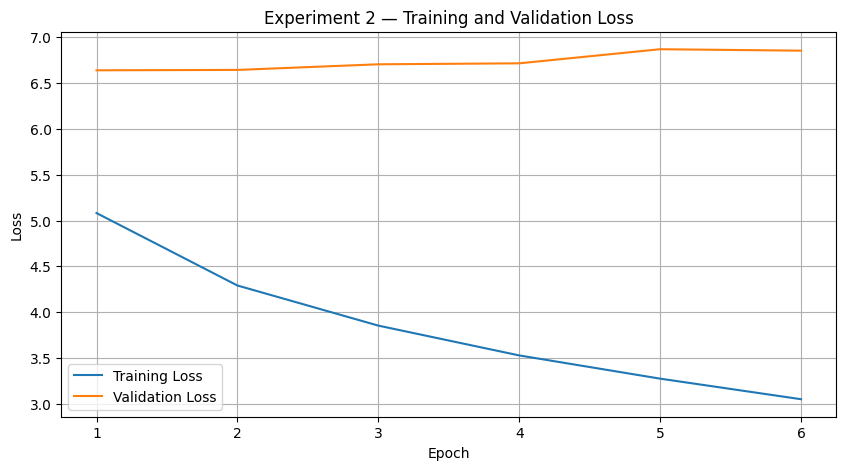

In [38]:
epochs_completed = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_completed,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs_completed,
    history["valid_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 2 — Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

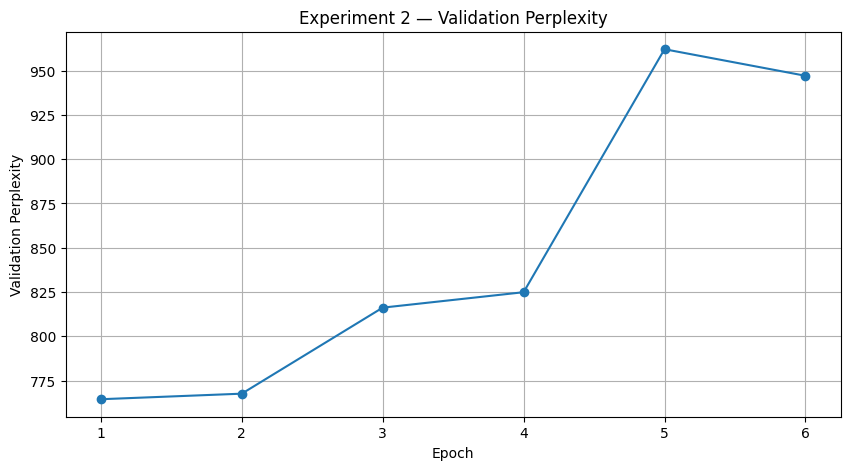

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs_completed,
    history["valid_ppl"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Perplexity")
plt.title("Experiment 2 — Validation Perplexity")

plt.grid(True)

plt.show()

In [40]:
best_epoch = (
    int(np.argmin(history["valid_loss"])) + 1
)

best_loss = min(history["valid_loss"])
best_ppl = history["valid_ppl"][best_epoch - 1]

print("=" * 80)
print("EXPERIMENT 2 TRAINING SUMMARY")
print("=" * 80)

print("Epochs completed:", len(history["train_loss"]))
print("Best epoch:", best_epoch)
print("Best validation loss:", best_loss)
print("Best validation perplexity:", best_ppl)
print("Best model:", BEST_MODEL_PATH)

EXPERIMENT 2 TRAINING SUMMARY
Epochs completed: 6
Best epoch: 1
Best validation loss: 6.6391770217069395
Best validation perplexity: 764.4655954744359
Best model: /kaggle/working/urdu-qgen-seq2seq/checkpoints/experiment-2/best_model.pt


In [41]:
assert BEST_MODEL_PATH.exists(), (
    "Best model checkpoint was not found."
)

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [42]:
def teacher_forced_accuracy(
    model,
    loader,
    max_batches=100
):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for batch_idx, (
            src,
            src_len,
            trg,
            _
        ) in enumerate(loader):

            if batch_idx >= max_batches:
                break

            src = src.to(
                DEVICE,
                non_blocking=True
            )

            src_len = src_len.to(DEVICE)

            trg = trg.to(
                DEVICE,
                non_blocking=True
            )

            output = model(
                src,
                src_len,
                trg,
                teacher_forcing_ratio=1.0
            )

            predictions = output.argmax(
                dim=2
            )

            # Ignore first BOS position
            predictions = predictions[1:]
            targets = trg[1:]

            mask = targets != PAD_IDX

            correct += (
                (predictions[mask] == targets[mask])
                .sum()
                .item()
            )

            total += mask.sum().item()

    return correct / total

In [43]:
train_accuracy = teacher_forced_accuracy(
    model,
    train_loader,
    max_batches=100
)

valid_accuracy = teacher_forced_accuracy(
    model,
    valid_loader,
    max_batches=100
)

print(
    f"Training token accuracy   : "
    f"{train_accuracy * 100:.2f}%"
)

print(
    f"Validation token accuracy : "
    f"{valid_accuracy * 100:.2f}%"
)

Training token accuracy   : 31.79%
Validation token accuracy : 29.58%


## Final Experiment 2 Results

The following metrics are saved locally and uploaded to Hugging Face.

These results will later be used when comparing Experiment 1 and
Experiment 2 and when preparing the final project documentation.

In [44]:
final_results = {
    "experiment": EXP_NAME,

    "best_epoch": best_epoch,

    "best_validation_loss": best_loss,

    "best_validation_perplexity": best_ppl,

    "training_token_accuracy":
        train_accuracy,

    "validation_token_accuracy":
        valid_accuracy,

    "epochs_completed":
        len(history["train_loss"]),

    "learning_rate":
        LEARNING_RATE,

    "teacher_forcing_ratio":
        TEACHER_FORCING_RATIO,

    "batch_size":
        BATCH_SIZE,

    "gradient_clip":
        GRAD_CLIP,

    "train_pairs":
        len(train_pairs),

    "validation_pairs":
        len(valid_pairs),

    "vocabulary_size":
        VOCAB_SIZE
}

FINAL_RESULTS_PATH = (
    RESULTS_DIR /
    f"{EXP_NAME}_final_results.json"
)

with open(
    FINAL_RESULTS_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_results,
        f,
        ensure_ascii=False,
        indent=2
    )

print(
    json.dumps(
        final_results,
        ensure_ascii=False,
        indent=2
    )
)

{
  "experiment": "experiment-2",
  "best_epoch": 1,
  "best_validation_loss": 6.6391770217069395,
  "best_validation_perplexity": 764.4655954744359,
  "training_token_accuracy": 0.3179182301057453,
  "validation_token_accuracy": 0.2958341314798092,
  "epochs_completed": 6,
  "learning_rate": 0.0003,
  "teacher_forcing_ratio": 0.8,
  "batch_size": 64,
  "gradient_clip": 1.0,
  "train_pairs": 75069,
  "validation_pairs": 10014,
  "vocabulary_size": 8000
}


In [45]:
api.upload_file(
    path_or_fileobj=str(FINAL_RESULTS_PATH),
    path_in_repo=f"{EXP_NAME}/final_results.json",
    repo_id=HF_REPO_ID,
    repo_type="model"
)

api.upload_file(
    path_or_fileobj=str(CONFIG_PATH),
    path_in_repo=f"{EXP_NAME}/config.json",
    repo_id=HF_REPO_ID,
    repo_type="model"
)

print("Final Experiment 2 results uploaded.")

No files have been modified since last commit. Skipping to prevent empty commit.


Final Experiment 2 results uploaded.


In [46]:
files = api.list_repo_files(
    repo_id=HF_REPO_ID,
    repo_type="model"
)

print("=" * 80)
print("HUGGING FACE REPOSITORY CONTENTS")
print("=" * 80)

for file in files:
    print(file)

HUGGING FACE REPOSITORY CONTENTS
.gitattributes
experiment-2/best_model.pt
experiment-2/config.json
experiment-2/epoch-01/checkpoint.pt
experiment-2/epoch-02/checkpoint.pt
experiment-2/epoch-03/checkpoint.pt
experiment-2/epoch-04/checkpoint.pt
experiment-2/epoch-05/checkpoint.pt
experiment-2/epoch-06/checkpoint.pt
experiment-2/final_results.json
experiment-2/history.json
tokenizer/ur_sp.model
tokenizer/ur_sp.vocab


In [47]:
print("=" * 80)
print("NOTEBOOK 3 — EXPERIMENT 2 COMPLETE")
print("=" * 80)

print()
print("Dataset:")
print(f"  Training pairs   : {len(train_pairs)}")
print(f"  Validation pairs : {len(valid_pairs)}")

print()
print("Model:")
print(f"  Vocabulary size  : {VOCAB_SIZE}")
print(f"  Parameters       : {n_params:,}")

print()
print("Training:")
print(f"  Epochs completed : {len(history['train_loss'])}")
print(f"  Best epoch       : {best_epoch}")
print(f"  Best valid loss  : {best_loss:.4f}")
print(f"  Best valid PPL   : {best_ppl:.2f}")

print()
print("Accuracy:")
print(
    f"  Train token acc  : "
    f"{train_accuracy * 100:.2f}%"
)
print(
    f"  Valid token acc  : "
    f"{valid_accuracy * 100:.2f}%"
)

print()
print("Hugging Face:")
print(f"  Repository       : {HF_REPO_ID}")

print()
print("Notebook 3 completed.")

NOTEBOOK 3 — EXPERIMENT 2 COMPLETE

Dataset:
  Training pairs   : 75069
  Validation pairs : 10014

Model:
  Vocabulary size  : 8000
  Parameters       : 35,505,984

Training:
  Epochs completed : 6
  Best epoch       : 1
  Best valid loss  : 6.6392
  Best valid PPL   : 764.47

Accuracy:
  Train token acc  : 31.79%
  Valid token acc  : 29.58%

Hugging Face:
  Repository       : razaasherazi/urdu-qgen-seq2seq

Notebook 3 completed.


# Diagnostic Analysis — Experiment 1 vs Experiment 2

Before starting another training experiment, we analyze:

1. Source and target sequence lengths
2. Answer-marker coverage
3. Training/validation data quality
4. Generated questions from the existing models
5. Differences between Experiment 1 and Experiment 2

This diagnostic phase does not perform any training.

In [48]:
print("=" * 80)
print("DATASET DIAGNOSTICS")
print("=" * 80)

print(f"Training examples   : {len(train_pairs):,}")
print(f"Validation examples : {len(valid_pairs):,}")

print()
print("Expected:")
print("Training examples   : 75,069")
print("Validation examples : 10,014")

DATASET DIAGNOSTICS
Training examples   : 75,069
Validation examples : 10,014

Expected:
Training examples   : 75,069
Validation examples : 10,014


## Answer Marker Analysis

The source text is expected to contain the answer inside:

<ans> ... </ans>

We check:

- how many examples contain both markers
- how many contain only one marker
- how many contain no markers
- whether the answer text between the markers is non-empty

In [49]:
def analyze_answer_markers(pairs):

    both = 0
    no_marker = 0
    opening_only = 0
    closing_only = 0
    empty_answer = 0

    answer_lengths = []

    for source, target in pairs:

        has_open = "<ans>" in source
        has_close = "</ans>" in source

        if has_open and has_close:
            both += 1

            start = source.find("<ans>") + len("<ans>")
            end = source.find("</ans>", start)

            answer = source[start:end].strip()

            if not answer:
                empty_answer += 1
            else:
                answer_lengths.append(
                    len(
                        sp.encode(
                            answer,
                            out_type=int
                        )
                    )
                )

        elif has_open:
            opening_only += 1

        elif has_close:
            closing_only += 1

        else:
            no_marker += 1

    return {
        "both": both,
        "no_marker": no_marker,
        "opening_only": opening_only,
        "closing_only": closing_only,
        "empty_answer": empty_answer,
        "answer_lengths": answer_lengths
    }


train_marker_stats = analyze_answer_markers(train_pairs)
valid_marker_stats = analyze_answer_markers(valid_pairs)

print("TRAINING")
print("-" * 50)

for key, value in train_marker_stats.items():
    if key != "answer_lengths":
        print(f"{key:20s}: {value:,}")

print()

print("VALIDATION")
print("-" * 50)

for key, value in valid_marker_stats.items():
    if key != "answer_lengths":
        print(f"{key:20s}: {value:,}")

TRAINING
--------------------------------------------------
both                : 75,069
no_marker           : 0
opening_only        : 0
closing_only        : 0
empty_answer        : 0

VALIDATION
--------------------------------------------------
both                : 10,014
no_marker           : 0
opening_only        : 0
closing_only        : 0
empty_answer        : 0


In [50]:
train_marker_total = len(train_pairs)
valid_marker_total = len(valid_pairs)

print("=" * 80)
print("ANSWER MARKER COVERAGE")
print("=" * 80)

print(
    f"Training with valid markers: "
    f"{train_marker_stats['both'] / train_marker_total * 100:.2f}%"
)

print(
    f"Validation with valid markers: "
    f"{valid_marker_stats['both'] / valid_marker_total * 100:.2f}%"
)

print(
    f"Training without markers: "
    f"{train_marker_stats['no_marker'] / train_marker_total * 100:.2f}%"
)

print(
    f"Validation without markers: "
    f"{valid_marker_stats['no_marker'] / valid_marker_total * 100:.2f}%"
)

ANSWER MARKER COVERAGE
Training with valid markers: 100.00%
Validation with valid markers: 100.00%
Training without markers: 0.00%
Validation without markers: 0.00%


## Sequence Length Analysis

We measure SentencePiece token lengths rather than character lengths,
because the model receives SentencePiece token IDs.

We calculate:

- minimum
- mean
- median
- 90th percentile
- 95th percentile
- 99th percentile
- maximum

In [51]:
def get_token_lengths(pairs):

    source_lengths = []
    target_lengths = []

    for source, target in pairs:

        source_ids = sp.encode(
            source,
            out_type=int
        )

        target_ids = sp.encode(
            target,
            out_type=int
        )

        # +2 for BOS and EOS
        source_lengths.append(
            len(source_ids) + 2
        )

        target_lengths.append(
            len(target_ids) + 2
        )

    return (
        np.array(source_lengths),
        np.array(target_lengths)
    )


train_src_lengths, train_tgt_lengths = get_token_lengths(
    train_pairs
)

valid_src_lengths, valid_tgt_lengths = get_token_lengths(
    valid_pairs
)

print("Length calculation complete.")

Length calculation complete.


In [53]:
def print_length_statistics(name, lengths):

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(f"Minimum       : {np.min(lengths)}")
    print(f"Mean          : {np.mean(lengths):.2f}")
    print(f"Median        : {np.median(lengths):.2f}")
    print(f"90th percentile: {np.percentile(lengths, 90):.2f}")
    print(f"95th percentile: {np.percentile(lengths, 95):.2f}")
    print(f"99th percentile: {np.percentile(lengths, 99):.2f}")
    print(f"Maximum       : {np.max(lengths)}")


print_length_statistics(
    "TRAINING SOURCE LENGTHS",
    train_src_lengths
)

print_length_statistics(
    "TRAINING TARGET LENGTHS",
    train_tgt_lengths
)

print_length_statistics(
    "VALIDATION SOURCE LENGTHS",
    valid_src_lengths
)

print_length_statistics(
    "VALIDATION TARGET LENGTHS",
    valid_tgt_lengths
)

TRAINING SOURCE LENGTHS
Minimum       : 7
Mean          : 43.86
Median        : 42.00
90th percentile: 66.00
95th percentile: 71.00
99th percentile: 83.00
Maximum       : 197
TRAINING TARGET LENGTHS
Minimum       : 3
Mean          : 17.15
Median        : 16.00
90th percentile: 24.00
95th percentile: 27.00
99th percentile: 32.00
Maximum       : 56
VALIDATION SOURCE LENGTHS
Minimum       : 9
Mean          : 44.97
Median        : 43.00
90th percentile: 67.00
95th percentile: 72.00
99th percentile: 84.00
Maximum       : 148
VALIDATION TARGET LENGTHS
Minimum       : 6
Mean          : 17.92
Median        : 17.00
90th percentile: 26.00
95th percentile: 28.00
99th percentile: 33.00
Maximum       : 47


## Long Sequence Analysis

Long source contexts can make it difficult for an LSTM encoder to
retain the answer information.

We therefore measure how many examples exceed several token lengths.

In [54]:
thresholds = [100, 150, 200, 250, 300, 400, 500]

print("=" * 80)
print("LONG SOURCE SEQUENCE DISTRIBUTION")
print("=" * 80)

for threshold in thresholds:

    train_count = np.sum(
        train_src_lengths > threshold
    )

    valid_count = np.sum(
        valid_src_lengths > threshold
    )

    print(
        f">{threshold:3d} tokens | "
        f"Train: {train_count:6,} "
        f"({train_count / len(train_src_lengths) * 100:6.2f}%) | "
        f"Valid: {valid_count:5,} "
        f"({valid_count / len(valid_src_lengths) * 100:6.2f}%)"
    )


LONG SOURCE SEQUENCE DISTRIBUTION
>100 tokens | Train:    174 (  0.23%) | Valid:    19 (  0.19%)
>150 tokens | Train:      4 (  0.01%) | Valid:     0 (  0.00%)
>200 tokens | Train:      0 (  0.00%) | Valid:     0 (  0.00%)
>250 tokens | Train:      0 (  0.00%) | Valid:     0 (  0.00%)
>300 tokens | Train:      0 (  0.00%) | Valid:     0 (  0.00%)
>400 tokens | Train:      0 (  0.00%) | Valid:     0 (  0.00%)
>500 tokens | Train:      0 (  0.00%) | Valid:     0 (  0.00%)


In [55]:
print("=" * 80)
print("TARGET QUESTION LENGTH DISTRIBUTION")
print("=" * 80)

thresholds = [10, 15, 20, 25, 30, 35, 40]

for threshold in thresholds:

    train_count = np.sum(
        train_tgt_lengths > threshold
    )

    valid_count = np.sum(
        valid_tgt_lengths > threshold
    )

    print(
        f">{threshold:2d} tokens | "
        f"Train: {train_count:6,} "
        f"({train_count / len(train_tgt_lengths) * 100:6.2f}%) | "
        f"Valid: {valid_count:5,} "
        f"({valid_count / len(valid_tgt_lengths) * 100:6.2f}%)"
    )

TARGET QUESTION LENGTH DISTRIBUTION
>10 tokens | Train: 69,885 ( 93.09%) | Valid: 9,429 ( 94.16%)
>15 tokens | Train: 42,612 ( 56.76%) | Valid: 6,213 ( 62.04%)
>20 tokens | Train: 17,743 ( 23.64%) | Valid: 2,841 ( 28.37%)
>25 tokens | Train:  5,600 (  7.46%) | Valid: 1,093 ( 10.91%)
>30 tokens | Train:  1,231 (  1.64%) | Valid:   250 (  2.50%)
>35 tokens | Train:    189 (  0.25%) | Valid:    41 (  0.41%)
>40 tokens | Train:     45 (  0.06%) | Valid:    15 (  0.15%)


## Random Training Examples

We inspect randomly selected examples instead of only looking at
the first few records.

This helps identify:

- malformed examples
- unusual contexts
- incorrect answer markers
- mismatched questions

In [56]:
random.seed(42)

sample_indices = random.sample(
    range(len(train_pairs)),
    10
)

for n, idx in enumerate(sample_indices, 1):

    source, target = train_pairs[idx]

    print("=" * 100)
    print(f"EXAMPLE {n} | INDEX {idx}")
    print("=" * 100)

    print("SOURCE:")
    print(source)

    print("\nTARGET QUESTION:")
    print(target)

EXAMPLE 1 | INDEX 14592
SOURCE:
شہر کے مرکز کے مغرب میں اب بھی فعال اور بڑھتی ہوئی ڈاک لینڈز کے باوجود ، <ans> 2009 </ans> میں چوتھے کروز ٹرمینل کے افتتاح کے ساتھ مزید بڑھایا گیا ہے ، مشرقی ڈاکوں کے کچھ حصوں کو دوبارہ تیار کیا گیا ہے۔

TARGET QUESTION:
کس سال مغربی ڈاک لینڈز میں ساؤتھمپٹن کا چوتھا کروز ٹرمینل کھولا گیا؟
EXAMPLE 2 | INDEX 3278
SOURCE:
نیو یارک کی ٹیموں نے 35 میجر لیگ بیس بال ورلڈ سیریز اور <ans> 73 </ans> پینٹ جیت لئے ہیں۔

TARGET QUESTION:
نیو یارک کی ٹیموں نے کتنے میجر لیگ بیس بال لیگ کے جھنڈے جیت لئے ہیں؟
EXAMPLE 3 | INDEX 36048
SOURCE:
<ans> 2010 تک ، افریقی نسل کے لوگوں نے فلوریڈا کی آبادی کا 16.0٪ حصہ لیا ، </ans> جس میں افریقی امریکی بھی شامل ہیں۔

TARGET QUESTION:
2010 میں فلوریڈا کا کتنا فیصد افریقی امریکی تھا
EXAMPLE 4 | INDEX 32098
SOURCE:
لہذا ، <ans> 16 ویں </ans> صدی میں ، ایک تفریق ہوئی۔

TARGET QUESTION:
مغربی جرمن زبانوں کے بارے میں الجھن کو واضح کرنے کے لئے کس صدی میں ایک فرق کیا گیا تھا؟
EXAMPLE 5 | INDEX 29256
SOURCE:
اس تجربے کے نتائج کو پوری دنیا م

## Validation Examples

The next section uses fixed validation examples.

These examples will later be used for an apples-to-apples comparison
between Experiment 1 and Experiment 2.

In [57]:
validation_sample_indices = [
    0,
    10,
    50,
    100,
    500,
    1000,
    2000,
    5000,
    8000,
    10000
]

for idx in validation_sample_indices:

    if idx >= len(valid_pairs):
        continue

    source, target = valid_pairs[idx]

    print("=" * 100)
    print(f"VALIDATION INDEX: {idx}")
    print("=" * 100)

    print("SOURCE:")
    print(source)

    print("\nREFERENCE:")
    print(target)

VALIDATION INDEX: 0
SOURCE:
نارمن (Norman: Nourmands؛ French: Normands؛ Latin: Normanni) وہ لوگ تھے جنہوں نے 10 ویں اور 11 ویں صدیوں میں <ans> فرانس </ans> کے ایک خطے نارمنڈی کو اپنا نام دیا۔

REFERENCE:
نارمنڈی کس ملک میں واقع ہے؟
VALIDATION INDEX: 10
SOURCE:
ڈچی آف نارمنڈی ، جسے انہوں نے فرانسیسی تاج کے ساتھ معاہدے کے ذریعہ تشکیل دیا ، قرون وسطی کے فرانس کا ایک عظیم فیوڈ تھا ، اور نارمنڈی کے <ans> رچرڈ اول </ans> کے تحت ایک مربوط اور خوفناک شہنشاہی میں تشکیل دیا گیا تھا۔

REFERENCE:
جو نورمنڈی کے ڈچی پر حکمرانی کی
VALIDATION INDEX: 50
SOURCE:
اس تعلقات نے بالآخر ڈیوک رچرڈ دوم آف نارمنڈی کی بہن ایما اور انگلینڈ کے بادشاہ <ans> ایتھلریڈ دوم </ans> کی شادی کے ذریعے خون کے قریبی تعلقات پیدا کیے۔

REFERENCE:
ایما نے کس سے شادی کی؟
VALIDATION INDEX: 100
SOURCE:
1402 اور 1405 کے درمیان ، نارمن شریف جین ڈی بیتینکورٹ اور پوئٹیوین گیڈیفر ڈی لا سال کی قیادت میں مہم نے <ans> افریقہ </ans> کے اٹلانٹک ساحل سے لانساروٹ ، فورٹی وینٹورا اور ایل ہیرو کے کینری جزیروں پر فتح حاصل کی۔

REFERENCE:
کن کنٹی

In [58]:
print("=" * 80)
print("SEARCHING FOR EXPERIMENT 1 CHECKPOINT")
print("=" * 80)

possible_paths = [
    PROJECT_ROOT / "checkpoints" / "best_model.pt",
    PROJECT_ROOT / "checkpoints" / "experiment-1" / "best_model.pt",
    PROJECT_ROOT / "checkpoints" / "experiment1" / "best_model.pt",
]

for path in possible_paths:
    print(f"{path} -> {path.exists()}")

SEARCHING FOR EXPERIMENT 1 CHECKPOINT
/kaggle/working/urdu-qgen-seq2seq/checkpoints/best_model.pt -> False
/kaggle/working/urdu-qgen-seq2seq/checkpoints/experiment-1/best_model.pt -> False
/kaggle/working/urdu-qgen-seq2seq/checkpoints/experiment1/best_model.pt -> False


In [59]:
print("=" * 80)
print("CHECKING HUGGING FACE FOR EXPERIMENT 1")
print("=" * 80)

hf_files = api.list_repo_files(
    repo_id=HF_REPO_ID,
    repo_type="model"
)

experiment1_files = [
    f for f in hf_files
    if "experiment-1" in f.lower()
    or "experiment1" in f.lower()
]

if experiment1_files:
    print("Experiment 1 files found:")
    for f in experiment1_files:
        print(f)
else:
    print("No Experiment 1 files found in Hugging Face.")

CHECKING HUGGING FACE FOR EXPERIMENT 1
No Experiment 1 files found in Hugging Face.


In [60]:
print("=" * 80)
print("COMBINED DATASET DIAGNOSTIC SUMMARY")
print("=" * 80)

print("\nDATASET SIZE")
print("-" * 40)
print(f"Training examples   : {len(train_pairs):,}")
print(f"Validation examples : {len(valid_pairs):,}")

print("\nANSWER MARKERS")
print("-" * 40)

print(
    f"Training valid markers : "
    f"{train_marker_stats['both']:,} "
    f"({train_marker_stats['both']/len(train_pairs)*100:.2f}%)"
)

print(
    f"Validation valid markers : "
    f"{valid_marker_stats['both']:,} "
    f"({valid_marker_stats['both']/len(valid_pairs)*100:.2f}%)"
)

print("\nSOURCE LENGTHS — TOKENS")
print("-" * 40)

print(
    f"Train mean   : {np.mean(train_src_lengths):.2f}"
)
print(
    f"Train median : {np.median(train_src_lengths):.2f}"
)
print(
    f"Train P95    : {np.percentile(train_src_lengths, 95):.2f}"
)
print(
    f"Train max    : {np.max(train_src_lengths)}"
)

print(
    f"Valid mean   : {np.mean(valid_src_lengths):.2f}"
)
print(
    f"Valid median : {np.median(valid_src_lengths):.2f}"
)
print(
    f"Valid P95    : {np.percentile(valid_src_lengths, 95):.2f}"
)
print(
    f"Valid max    : {np.max(valid_src_lengths)}"
)

print("\nTARGET LENGTHS — TOKENS")
print("-" * 40)

print(
    f"Train mean   : {np.mean(train_tgt_lengths):.2f}"
)
print(
    f"Train median : {np.median(train_tgt_lengths):.2f}"
)
print(
    f"Train P95    : {np.percentile(train_tgt_lengths, 95):.2f}"
)
print(
    f"Train max    : {np.max(train_tgt_lengths)}"
)

print(
    f"Valid mean   : {np.mean(valid_tgt_lengths):.2f}"
)
print(
    f"Valid median : {np.median(valid_tgt_lengths):.2f}"
)
print(
    f"Valid P95    : {np.percentile(valid_tgt_lengths, 95):.2f}"
)
print(
    f"Valid max    : {np.max(valid_tgt_lengths)}"
)

COMBINED DATASET DIAGNOSTIC SUMMARY

DATASET SIZE
----------------------------------------
Training examples   : 75,069
Validation examples : 10,014

ANSWER MARKERS
----------------------------------------
Training valid markers : 75,069 (100.00%)
Validation valid markers : 10,014 (100.00%)

SOURCE LENGTHS — TOKENS
----------------------------------------
Train mean   : 43.86
Train median : 42.00
Train P95    : 71.00
Train max    : 197
Valid mean   : 44.97
Valid median : 43.00
Valid P95    : 72.00
Valid max    : 148

TARGET LENGTHS — TOKENS
----------------------------------------
Train mean   : 17.15
Train median : 16.00
Train P95    : 27.00
Train max    : 56
Valid mean   : 17.92
Valid median : 17.00
Valid P95    : 28.00
Valid max    : 47


In [61]:
print("=" * 80)
print("MAXIMUM TARGET LENGTH ANALYSIS")
print("=" * 80)

MAX_TGT_LEN = 30

train_over = np.sum(train_tgt_lengths > MAX_TGT_LEN)
valid_over = np.sum(valid_tgt_lengths > MAX_TGT_LEN)

print(
    f"Training questions > {MAX_TGT_LEN} tokens: "
    f"{train_over:,} "
    f"({train_over / len(train_tgt_lengths) * 100:.2f}%)"
)

print(
    f"Validation questions > {MAX_TGT_LEN} tokens: "
    f"{valid_over:,} "
    f"({valid_over / len(valid_tgt_lengths) * 100:.2f}%)"
)

MAXIMUM TARGET LENGTH ANALYSIS
Training questions > 30 tokens: 1,231 (1.64%)
Validation questions > 30 tokens: 250 (2.50%)


In [62]:
print("=" * 80)
print("ANSWER LENGTH ANALYSIS")
print("=" * 80)

train_answer_lengths = np.array(
    train_marker_stats["answer_lengths"]
)

valid_answer_lengths = np.array(
    valid_marker_stats["answer_lengths"]
)

for name, lengths in [
    ("Training", train_answer_lengths),
    ("Validation", valid_answer_lengths)
]:

    print(f"\n{name}")
    print("-" * 40)

    print(f"Mean   : {np.mean(lengths):.2f}")
    print(f"Median : {np.median(lengths):.2f}")
    print(f"P95    : {np.percentile(lengths, 95):.2f}")
    print(f"Max    : {np.max(lengths)}")

ANSWER LENGTH ANALYSIS

Training
----------------------------------------
Mean   : 4.81
Median : 3.00
P95    : 14.00
Max    : 88

Validation
----------------------------------------
Mean   : 5.41
Median : 4.00
P95    : 16.00
Max    : 49


In [63]:
def generate_question(
    model,
    source_text,
    max_len=30
):

    model.eval()

    source_ids = (
        [BOS_IDX]
        + sp.encode(source_text, out_type=int)
        + [EOS_IDX]
    )

    src_tensor = torch.tensor(
        source_ids,
        dtype=torch.long,
        device=DEVICE
    ).unsqueeze(1)

    src_length = torch.tensor(
        [len(source_ids)],
        dtype=torch.long,
        device=DEVICE
    )

    with torch.no_grad():

        encoder_outputs, hidden, cell = model.encoder(
            src_tensor,
            src_length
        )

    mask = model.create_mask(src_tensor)

    input_token = torch.tensor(
        [BOS_IDX],
        dtype=torch.long,
        device=DEVICE
    )

    generated_ids = []

    with torch.no_grad():

        for _ in range(max_len):

            output, hidden, cell, attention = model.decoder(
                input_token,
                hidden,
                cell,
                encoder_outputs,
                mask
            )

            predicted_token = output.argmax(
                1
            )

            token_id = predicted_token.item()

            if token_id == EOS_IDX:
                break

            if token_id != PAD_IDX:
                generated_ids.append(token_id)

            input_token = predicted_token

    if not generated_ids:
        return ""

    return sp.decode(
        generated_ids
    )

In [64]:
print("=" * 80)
print("LOADING EXPERIMENT 2 BEST MODEL")
print("=" * 80)

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)

model.eval()

print("Loaded:")
print(BEST_MODEL_PATH)
print()
print("Best epoch:", best_epoch)
print("Best validation loss:", best_loss)

LOADING EXPERIMENT 2 BEST MODEL
Loaded:
/kaggle/working/urdu-qgen-seq2seq/checkpoints/experiment-2/best_model.pt

Best epoch: 1
Best validation loss: 6.6391770217069395


In [65]:
print("=" * 100)
print("EXPERIMENT 2 — GENERATION RESULTS")
print("=" * 100)

for idx in validation_sample_indices:

    if idx >= len(valid_pairs):
        continue

    source, reference = valid_pairs[idx]

    generated = generate_question(
        model,
        source,
        max_len=30
    )

    print("\n" + "=" * 100)
    print(f"VALIDATION INDEX: {idx}")
    print("=" * 100)

    print("SOURCE:")
    print(source)

    print("\nREFERENCE QUESTION:")
    print(reference)

    print("\nGENERATED QUESTION:")
    print(generated)

EXPERIMENT 2 — GENERATION RESULTS

VALIDATION INDEX: 0
SOURCE:
نارمن (Norman: Nourmands؛ French: Normands؛ Latin: Normanni) وہ لوگ تھے جنہوں نے 10 ویں اور 11 ویں صدیوں میں <ans> فرانس </ans> کے ایک خطے نارمنڈی کو اپنا نام دیا۔

REFERENCE QUESTION:
نارمنڈی کس ملک میں واقع ہے؟

GENERATED QUESTION:
کون سا گروپ نے اپنے آپ کو دوبارہ طور پر کیا؟

VALIDATION INDEX: 10
SOURCE:
ڈچی آف نارمنڈی ، جسے انہوں نے فرانسیسی تاج کے ساتھ معاہدے کے ذریعہ تشکیل دیا ، قرون وسطی کے فرانس کا ایک عظیم فیوڈ تھا ، اور نارمنڈی کے <ans> رچرڈ اول </ans> کے تحت ایک مربوط اور خوفناک شہنشاہی میں تشکیل دیا گیا تھا۔

REFERENCE QUESTION:
جو نورمنڈی کے ڈچی پر حکمرانی کی

GENERATED QUESTION:
کون سا گروپ نے اپنے آپ کو کس کے ساتھ ساتھ کیا؟

VALIDATION INDEX: 50
SOURCE:
اس تعلقات نے بالآخر ڈیوک رچرڈ دوم آف نارمنڈی کی بہن ایما اور انگلینڈ کے بادشاہ <ans> ایتھلریڈ دوم </ans> کی شادی کے ذریعے خون کے قریبی تعلقات پیدا کیے۔

REFERENCE QUESTION:
ایما نے کس سے شادی کی؟

GENERATED QUESTION:
کون سا گروپ نے اپنے آپ کو کس کے ساتھ ساتھ ک

In [66]:
print("=" * 100)
print("ANSWER MARKER ABLATION TEST")
print("=" * 100)

idx = 0

source, reference = valid_pairs[idx]

source_without_markers = (
    source
    .replace("<ans>", "")
    .replace("</ans>", "")
)

with_markers = generate_question(
    model,
    source,
    max_len=30
)

without_markers = generate_question(
    model,
    source_without_markers,
    max_len=30
)

print("SOURCE WITH ANSWER MARKERS:")
print(source)

print("\nREFERENCE:")
print(reference)

print("\nGENERATED WITH MARKERS:")
print(with_markers)

print("\nGENERATED WITHOUT MARKERS:")
print(without_markers)

ANSWER MARKER ABLATION TEST
SOURCE WITH ANSWER MARKERS:
نارمن (Norman: Nourmands؛ French: Normands؛ Latin: Normanni) وہ لوگ تھے جنہوں نے 10 ویں اور 11 ویں صدیوں میں <ans> فرانس </ans> کے ایک خطے نارمنڈی کو اپنا نام دیا۔

REFERENCE:
نارمنڈی کس ملک میں واقع ہے؟

GENERATED WITH MARKERS:
کون سا گروپ نے اپنے آپ کو دوبارہ طور پر کیا؟

GENERATED WITHOUT MARKERS:
کون سا گروپ نے اپنے آپ کو کیا کہا جاتا تھا؟


# Notebook 4 — Model Evaluation

This notebook evaluates the trained Urdu Question Generation model on:

1. UQA validation set — in-domain evaluation
2. Wiki-UQA test set — out-of-domain evaluation

Evaluation metrics:

- Validation perplexity
- BLEU-4
- ROUGE-L
- UNK rate

Both decoding strategies are evaluated:

- Greedy decoding
- Beam search with beam width = 5

The notebook also saves:

- results/samples.tsv
- evaluation metrics
- attention heatmap
- representative generated examples

In [67]:
import csv
import json
import math
import os
import random
from pathlib import Path

import sacrebleu
from rouge_score import rouge_scorer

from datasets import load_dataset

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

print("Evaluation imports successful.")

Evaluation imports successful.


## Project Paths

The project is located at:

/kaggle/working/urdu-qgen-seq2seq

The evaluation results will be stored inside:

results/

In [68]:
PROJECT_ROOT = Path(
    "/kaggle/working/urdu-qgen-seq2seq"
).resolve()

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "experiment-2"
    / "best_model.pt"
)

print("Project root:")
print(PROJECT_ROOT)

print("\nBest model:")
print(BEST_MODEL_PATH)

print("\nBest model exists:", BEST_MODEL_PATH.exists())

assert BEST_MODEL_PATH.exists(), (
    "Experiment 2 best model was not found."
)

Project root:
/kaggle/working/urdu-qgen-seq2seq

Best model:
/kaggle/working/urdu-qgen-seq2seq/checkpoints/experiment-2/best_model.pt

Best model exists: True


## Load the Best Experiment 2 Model

Experiment 2 selected Epoch 1 as its best checkpoint:

Validation loss = 6.6392

The model is loaded before evaluation so all metrics are calculated
using the same best checkpoint.

In [69]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)

model.eval()

print("Best Experiment 2 model loaded successfully.")
print("Validation loss:", best_loss)
print("Best epoch:", best_epoch)

Best Experiment 2 model loaded successfully.
Validation loss: 6.6391770217069395
Best epoch: 1


## UQA Validation Perplexity

Perplexity is calculated from the validation cross-entropy loss.

Lower perplexity indicates that the model assigns higher probability
to the reference target sequences.

In [70]:
@torch.no_grad()
def compute_perplexity(
    model,
    loader,
    criterion
):

    val_loss = eval_epoch(
        model,
        loader,
        criterion
    )

    return math.exp(val_loss)


uqa_valid_loss = eval_epoch(
    model,
    valid_loader,
    criterion
)

uqa_valid_ppl = math.exp(
    uqa_valid_loss
)

print(
    f"UQA validation loss: "
    f"{uqa_valid_loss:.4f}"
)

print(
    f"UQA validation perplexity: "
    f"{uqa_valid_ppl:.2f}"
)

UQA validation loss: 6.6392
UQA validation perplexity: 764.47


## Greedy Decoding

Greedy decoding selects the highest-probability token at every
decoding step.

At each step:

current token
→ decoder
→ vocabulary probabilities
→ argmax
→ next token

In [71]:
@torch.no_grad()
def greedy_decode(
    model,
    sp,
    source_text,
    max_len=30
):

    model.eval()

    source_ids = (
        [BOS_IDX]
        + sp.encode(
            source_text,
            out_type=int
        )
        + [EOS_IDX]
    )

    src_tensor = torch.tensor(
        source_ids,
        dtype=torch.long,
        device=DEVICE
    ).unsqueeze(1)

    src_length = torch.tensor(
        [len(source_ids)],
        dtype=torch.long,
        device=DEVICE
    )

    encoder_outputs, hidden, cell = (
        model.encoder(
            src_tensor,
            src_length
        )
    )

    mask = model.create_mask(
        src_tensor
    )

    input_token = torch.tensor(
        [BOS_IDX],
        dtype=torch.long,
        device=DEVICE
    )

    generated_ids = []

    for _ in range(max_len):

        output, hidden, cell, _ = (
            model.decoder(
                input_token,
                hidden,
                cell,
                encoder_outputs,
                mask
            )
        )

        predicted_token = output.argmax(
            dim=1
        )

        token_id = predicted_token.item()

        if token_id == EOS_IDX:
            break

        if token_id != PAD_IDX:
            generated_ids.append(
                token_id
            )

        input_token = predicted_token

    return sp.decode(
        generated_ids
    )

In [72]:
source, reference = valid_pairs[0]

generated = greedy_decode(
    model,
    sp,
    source
)

print("SOURCE:")
print(source)

print("\nREFERENCE:")
print(reference)

print("\nGREEDY:")
print(generated)

SOURCE:
نارمن (Norman: Nourmands؛ French: Normands؛ Latin: Normanni) وہ لوگ تھے جنہوں نے 10 ویں اور 11 ویں صدیوں میں <ans> فرانس </ans> کے ایک خطے نارمنڈی کو اپنا نام دیا۔

REFERENCE:
نارمنڈی کس ملک میں واقع ہے؟

GREEDY:
کون سا گروپ نے اپنے آپ کو دوبارہ طور پر کیا؟


## Beam Search

Beam search keeps multiple candidate sequences instead of committing
to a single token at every step.

Beam width:

5

The highest-scoring completed sequence is returned.

In [73]:
@torch.no_grad()
def beam_search_decode(
    model,
    sp,
    source_text,
    beam_width=5,
    max_len=30
):

    model.eval()

    source_ids = (
        [BOS_IDX]
        + sp.encode(
            source_text,
            out_type=int
        )
        + [EOS_IDX]
    )

    src_tensor = torch.tensor(
        source_ids,
        dtype=torch.long,
        device=DEVICE
    ).unsqueeze(1)

    src_length = torch.tensor(
        [len(source_ids)],
        dtype=torch.long,
        device=DEVICE
    )

    encoder_outputs, hidden, cell = (
        model.encoder(
            src_tensor,
            src_length
        )
    )

    mask = model.create_mask(
        src_tensor
    )

    # Each beam:
    # (token_ids, score, hidden, cell)

    beams = [
        (
            [BOS_IDX],
            0.0,
            hidden,
            cell
        )
    ]

    completed = []

    for _ in range(max_len):

        candidates = []

        for tokens, score, h, c in beams:

            if tokens[-1] == EOS_IDX:

                completed.append(
                    (tokens, score)
                )

                continue

            input_token = torch.tensor(
                [tokens[-1]],
                dtype=torch.long,
                device=DEVICE
            )

            output, new_h, new_c, _ = (
                model.decoder(
                    input_token,
                    h,
                    c,
                    encoder_outputs,
                    mask
                )
            )

            log_probs = torch.log_softmax(
                output,
                dim=1
            )

            top_scores, top_indices = (
                torch.topk(
                    log_probs,
                    beam_width,
                    dim=1
                )
            )

            for k in range(beam_width):

                token_id = (
                    top_indices[0, k]
                    .item()
                )

                token_score = (
                    top_scores[0, k]
                    .item()
                )

                new_tokens = (
                    tokens + [token_id]
                )

                new_score = (
                    score + token_score
                )

                candidates.append(
                    (
                        new_tokens,
                        new_score,
                        new_h,
                        new_c
                    )
                )

        if not candidates:
            break

        candidates.sort(
            key=lambda x: x[1],
            reverse=True
        )

        beams = candidates[
            :beam_width
        ]

    # Add unfinished beams
    for tokens, score, _, _ in beams:
        completed.append(
            (tokens, score)
        )

    if not completed:
        return ""

    # Length-normalized score
    def normalized_score(item):

        tokens, score = item

        length = max(
            1,
            len(tokens) - 1
        )

        return score / length

    completed.sort(
        key=normalized_score,
        reverse=True
    )

    best_tokens = completed[0][0]

    generated_ids = []

    for token_id in best_tokens:

        if token_id in (
            BOS_IDX,
            EOS_IDX,
            PAD_IDX
        ):
            continue

        generated_ids.append(
            token_id
        )

    return sp.decode(
        generated_ids
    )

In [74]:
source, reference = valid_pairs[0]

generated_beam = beam_search_decode(
    model,
    sp,
    source,
    beam_width=5
)

print("SOURCE:")
print(source)

print("\nREFERENCE:")
print(reference)

print("\nBEAM SEARCH:")
print(generated_beam)

SOURCE:
نارمن (Norman: Nourmands؛ French: Normands؛ Latin: Normanni) وہ لوگ تھے جنہوں نے 10 ویں اور 11 ویں صدیوں میں <ans> فرانس </ans> کے ایک خطے نارمنڈی کو اپنا نام دیا۔

REFERENCE:
نارمنڈی کس ملک میں واقع ہے؟

BEAM SEARCH:
کون سی دوسری جنگ عظیموں کو کس کے لئے جانا جاتا تھا؟


## Evaluation Metrics

BLEU-4 and ROUGE-L compare generated questions with reference questions.

UNK rate measures the proportion of unknown-token glyphs in the
generated text.

In [75]:
def score(
    hyps,
    refs
):

    bleu = sacrebleu.corpus_bleu(
        hyps,
        [refs]
    ).score

    scorer = rouge_scorer.RougeScorer(
        ["rougeL"],
        use_stemmer=False
    )

    rouge_scores = []

    for hyp, ref in zip(
        hyps,
        refs
    ):

        rouge_scores.append(
            scorer.score(
                ref,
                hyp
            )["rougeL"].fmeasure
        )

    rouge_l = (
        sum(rouge_scores)
        / max(1, len(rouge_scores))
    )

    total_unk = sum(
        hyp.count("\u2047")
        for hyp in hyps
    )

    total_words = sum(
        len(hyp.split())
        for hyp in hyps
    )

    unk_rate = (
        total_unk
        / max(1, total_words)
    )

    return {
        "BLEU-4": bleu,
        "ROUGE-L": rouge_l,
        "unk_rate": unk_rate
    }

## UQA Validation Generation

The full UQA validation set contains 10,014 examples.

We generate both:

- Greedy questions
- Beam-search questions

This may take some time because every validation example requires
autoregressive decoding.

In [76]:
uqa_src = []
uqa_refs = []
uqa_greedy = []
uqa_beam = []

print(
    f"Generating predictions for "
    f"{len(valid_pairs):,} UQA validation examples..."
)

for i, (src, tgt) in enumerate(
    valid_pairs,
    start=1
):

    greedy = greedy_decode(
        model,
        sp,
        src
    )

    beam = beam_search_decode(
        model,
        sp,
        src,
        beam_width=5
    )

    uqa_src.append(src)
    uqa_refs.append(tgt)
    uqa_greedy.append(greedy)
    uqa_beam.append(beam)

    if i % 500 == 0:
        print(
            f"Completed {i:,} / "
            f"{len(valid_pairs):,}"
        )

print("UQA generation complete.")

Generating predictions for 10,014 UQA validation examples...
Completed 500 / 10,014
Completed 1,000 / 10,014
Completed 1,500 / 10,014
Completed 2,000 / 10,014
Completed 2,500 / 10,014
Completed 3,000 / 10,014
Completed 3,500 / 10,014
Completed 4,000 / 10,014
Completed 4,500 / 10,014
Completed 5,000 / 10,014
Completed 5,500 / 10,014
Completed 6,000 / 10,014
Completed 6,500 / 10,014
Completed 7,000 / 10,014
Completed 7,500 / 10,014
Completed 8,000 / 10,014
Completed 8,500 / 10,014
Completed 9,000 / 10,014
Completed 9,500 / 10,014
Completed 10,000 / 10,014
UQA generation complete.


In [77]:
uqa_greedy_scores = score(
    uqa_greedy,
    uqa_refs
)

uqa_beam_scores = score(
    uqa_beam,
    uqa_refs
)

print("=" * 80)
print("UQA VALIDATION RESULTS")
print("=" * 80)

print("\nGreedy:")
for key, value in uqa_greedy_scores.items():
    print(f"{key:12s}: {value:.6f}")

print("\nBeam Search:")
for key, value in uqa_beam_scores.items():
    print(f"{key:12s}: {value:.6f}")

UQA VALIDATION RESULTS

Greedy:
BLEU-4      : 1.300484
ROUGE-L     : 0.000799
unk_rate    : 0.000000

Beam Search:
BLEU-4      : 1.633435
ROUGE-L     : 0.000999
unk_rate    : 0.000000


## Wiki-UQA

Wiki-UQA is used as an out-of-domain evaluation set.

The same pair-construction procedure used during data preparation
must be used here.

The original Task 4 specifies the Wiki-UQA test split.

In [78]:
wiki_ds = load_dataset(
    "uqa/Wiki-UQA"
)

print(wiki_ds)

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 210
    })
})


In [79]:
print("Available Wiki-UQA splits:")

for split_name in wiki_ds.keys():
    print(
        split_name,
        "->",
        len(wiki_ds[split_name])
    )

Available Wiki-UQA splits:
train -> 210


In [80]:
# ## Rebuild Wiki-UQA Pairs

# The following cell attempts to reconstruct the Wiki-UQA
# source-target pairs using the same answer-marking logic as
# Notebook 1.

# The exact dataset schema is inspected before constructing pairs.

wiki_split_name = (
    "test"
    if "test" in wiki_ds
    else list(wiki_ds.keys())[0]
)

wiki_split = wiki_ds[
    wiki_split_name
]

print("Using split:", wiki_split_name)

print("\nColumns:")
print(wiki_split.column_names)

print("\nFirst example:")
print(wiki_split[0])

Using split: train

Columns:
['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start']

First example:
{'id': 'bc6568b3-2cab-4b5b-aba6-c2c4301e3fe0', 'title': 'صہیونیت', 'context': 'صیہونیت (؛ \xa0از) قومی تحریک ہے جو یہودی لوگوں کی دوبارہ یہودی وطن یعنی\xa0 ملک اسرائیل\xa0(جو\xa0\xa0کنعان، ارض مقدس\xa0اور\xa0فلسطین پر مشتمل ہے)۔ قیام کی حمایت کرتی ہے جدید صیہونیت انیسویں صدی\xa0کے اواخر میں وسطی اور مشرقی یورپ\xa0میں ایک یہودی قومی احیاء کی تحریک کے طور پر \xa0ابھر کر سامنے آئی، جس نے\xa0سام دشمنی\xa0کے رد عمل اور\xa0اخراجی قوم پرست تحریکوں کے جواب میں جنم لیا۔ اس کے بعد جلد ہی، اس کے زیادہ تر رہنماؤں نے اس تحریک کا مقصد\xa0 مطلوبہ ریاست فلسطین اور بعد میں سلطنت عثمانیہ\xa0 کے زیر حکومت علاقوں میں\xa0 قائم کرنے سے وابستہ کر لیا۔', 'question': 'جدید صیہونیت کس علاقے میں نمودار ہوئی؟', 'is_impossible': False, 'answer': 'وسطی اور مشرقی یورپ', 'answer_start': 189}


In [90]:
wiki_processed_candidates = [
    PROJECT_ROOT / "data" / "processed" / "wiki_uqa.tsv",
    PROJECT_ROOT / "data" / "processed" / "wiki-uqa.tsv",
    PROJECT_ROOT / "data" / "processed" / "wiki_test.tsv",
]

for path in wiki_processed_candidates:
    print(
        f"{path} -> {path.exists()}"
    )
    

/kaggle/working/urdu-qgen-seq2seq/data/processed/wiki_uqa.tsv -> False
/kaggle/working/urdu-qgen-seq2seq/data/processed/wiki-uqa.tsv -> False
/kaggle/working/urdu-qgen-seq2seq/data/processed/wiki_test.tsv -> False


In [91]:
# =========================================================
# CELL 137 — Load processed Wiki-UQA evaluation pairs
# =========================================================

wiki_path = PROJECT_ROOT / "data" / "processed" / "wiki_valid.tsv"

print(f"Loading Wiki-UQA pairs from:")
print(wiki_path)

wiki_pairs = load_pairs(wiki_path)

print(f"\nWiki-UQA pairs loaded: {len(wiki_pairs):,}")

# Show a couple of examples
for i, (src, tgt) in enumerate(wiki_pairs[:2], start=1):
    print(f"\nExample {i}")
    print("Source  :", src[:300])
    print("Target  :", tgt)

Loading Wiki-UQA pairs from:
/kaggle/working/urdu-qgen-seq2seq/data/processed/wiki_valid.tsv

Wiki-UQA pairs loaded: 178

Example 1
Source  : قیام کی حمایت کرتی ہے جدید صیہونیت انیسویں صدی کے اواخر میں <ans> وسطی اور مشرقی یورپ </ans> میں ایک یہودی قومی احیاء کی تحریک کے طور پر ابھر کر سامنے آئی، جس نے سام دشمنی کے رد عمل اور اخراجی قوم پرست تحریکوں کے جواب میں جنم لیا۔
Target  : جدید صیہونیت کس علاقے میں نمودار ہوئی؟

Example 2
Source  : قیام کی حمایت کرتی ہے جدید صیہونیت <ans> انیسویں صدی </ans> کے اواخر میں وسطی اور مشرقی یورپ میں ایک یہودی قومی احیاء کی تحریک کے طور پر ابھر کر سامنے آئی، جس نے سام دشمنی کے رد عمل اور اخراجی قوم پرست تحریکوں کے جواب میں جنم لیا۔
Target  : جدید صیہونیت کس صدی میں نمودار ہوئی؟


In [93]:
# =========================================================
# CELL 138B — Prediction generation helper
# =========================================================

def generate_predictions(model, sp, pairs, beam_width=5, limit=None):
    """
    Generate greedy and beam-search predictions for a list
    of (source, reference) pairs.
    """

    subset = pairs[:limit] if limit is not None else pairs

    sources = []
    refs = []
    greedy_hyps = []
    beam_hyps = []

    for i, (src, tgt) in enumerate(subset, start=1):

        greedy = greedy_decode(
            model,
            sp,
            src
        )

        beam = beam_search_decode(
            model,
            sp,
            src,
            beam_width=beam_width
        )

        sources.append(src)
        refs.append(tgt)
        greedy_hyps.append(greedy)
        beam_hyps.append(beam)

        if i % 25 == 0 or i == len(subset):
            print(f"Processed {i:,}/{len(subset):,}")

    return sources, refs, greedy_hyps, beam_hyps

In [114]:
# ## Wiki-UQA Prediction Generation

# The same greedy and beam-search decoders used for UQA validation
# are applied to Wiki-UQA.

# This provides an out-of-domain comparison.

# =========================================================
# CELL 139 — Generate Wiki-UQA predictions
# =========================================================

print(
    f"Generating predictions for "
    f"{len(wiki_pairs):,} Wiki-UQA examples..."
)

wiki_src, wiki_refs, wiki_greedy, wiki_beam = generate_predictions(
    model,
    sp,
    wiki_pairs,
    beam_width=5
)

print("\nWiki-UQA generation complete.")

print(f"Sources     : {len(wiki_src):,}")
print(f"References  : {len(wiki_refs):,}")
print(f"Greedy hyps : {len(wiki_greedy):,}")
print(f"Beam hyps   : {len(wiki_beam):,}")

Generating predictions for 178 Wiki-UQA examples...
Processed 25/178
Processed 50/178
Processed 75/178
Processed 100/178
Processed 125/178
Processed 150/178
Processed 175/178
Processed 178/178

Wiki-UQA generation complete.
Sources     : 178
References  : 178
Greedy hyps : 178
Beam hyps   : 178


In [115]:
wiki_greedy_scores = score(
    wiki_greedy,
    wiki_refs
)

wiki_beam_scores = score(
    wiki_beam,
    wiki_refs
)

print("=" * 80)
print("WIKI-UQA RESULTS")
print("=" * 80)

print("\nGreedy:")
for key, value in wiki_greedy_scores.items():
    print(f"{key:12s}: {value:.6f}")

print("\nBeam Search:")
for key, value in wiki_beam_scores.items():
    print(f"{key:12s}: {value:.6f}")

WIKI-UQA RESULTS

Greedy:
BLEU-4      : 0.602026
ROUGE-L     : 0.000000
unk_rate    : 0.000000

Beam Search:
BLEU-4      : 0.562052
ROUGE-L     : 0.000000
unk_rate    : 0.000000


In [118]:
# =========================================================
# CELL 142 — Final evaluation table
# =========================================================

import pandas as pd

evaluation_rows = [
    {
        "Dataset": "UQA Validation",
        "Decoder": "Greedy",
        **uqa_greedy_scores
    },
    {
        "Dataset": "UQA Validation",
        "Decoder": "Beam-5",
        **uqa_beam_scores
    },
    {
        "Dataset": "Wiki-UQA",
        "Decoder": "Greedy",
        **wiki_greedy_scores
    },
    {
        "Dataset": "Wiki-UQA",
        "Decoder": "Beam-5",
        **wiki_beam_scores
    },
]

evaluation_df = pd.DataFrame(evaluation_rows)

evaluation_df

,Dataset,Decoder,BLEU-4,ROUGE-L,unk_rate
0,UQA Validation,Greedy,1.300484,0.000799,0.0
1,UQA Validation,Beam-5,1.633435,0.000999,0.0
2,Wiki-UQA,Greedy,0.602026,0.000000,0.0
3,Wiki-UQA,Beam-5,0.562052,0.000000,0.0


In [117]:
evaluation_csv = (
    RESULTS_DIR /
    "evaluation_metrics.csv"
)

evaluation_table.to_csv(
    evaluation_csv,
    index=False
)

print(
    "Saved:",
    evaluation_csv
)

Saved: /kaggle/working/urdu-qgen-seq2seq/results/evaluation_metrics.csv


In [98]:
# ## Save Generated Samples

# The original Task 4 requires at least 50 examples containing:

# - source
# - reference
# - greedy prediction
# - beam prediction

# The first 50 UQA validation examples are saved.

def save_samples(
    path,
    sources,
    refs,
    greedy_hyps,
    beam_hyps,
    n=50
):

    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    with open(
        path,
        "w",
        encoding="utf-8",
        newline=""
    ) as f:

        writer = csv.writer(
            f,
            delimiter="\t"
        )

        writer.writerow([
            "source",
            "reference",
            "greedy",
            "beam"
        ])

        for i in range(
            min(n, len(sources))
        ):

            writer.writerow([
                sources[i],
                refs[i],
                greedy_hyps[i],
                beam_hyps[i]
            ])

    print(
        f"Saved {min(n, len(sources))} examples:"
    )
    print(path)


SAMPLES_PATH = (
    RESULTS_DIR /
    "samples.tsv"
)

save_samples(
    SAMPLES_PATH,
    uqa_src,
    uqa_refs,
    uqa_greedy,
    uqa_beam,
    n=50
)

Saved 50 examples:
/kaggle/working/urdu-qgen-seq2seq/results/samples.tsv


In [99]:
# ## Representative Real Outputs

# These examples will also be useful for the final report and Medium
# article.

# We display several actual model outputs rather than manually
# constructed examples.

print("=" * 100)
print("REPRESENTATIVE MODEL OUTPUTS")
print("=" * 100)

for i in range(
    min(10, len(uqa_src))
):

    print("\n" + "=" * 100)
    print(f"EXAMPLE {i + 1}")
    print("=" * 100)

    print("SOURCE:")
    print(uqa_src[i])

    print("\nREFERENCE:")
    print(uqa_refs[i])

    print("\nGREEDY:")
    print(uqa_greedy[i])

    print("\nBEAM-5:")
    print(uqa_beam[i])

REPRESENTATIVE MODEL OUTPUTS

EXAMPLE 1
SOURCE:
نارمن (Norman: Nourmands؛ French: Normands؛ Latin: Normanni) وہ لوگ تھے جنہوں نے 10 ویں اور 11 ویں صدیوں میں <ans> فرانس </ans> کے ایک خطے نارمنڈی کو اپنا نام دیا۔

REFERENCE:
نارمنڈی کس ملک میں واقع ہے؟

GREEDY:
کون سا گروپ نے اپنے آپ کو دوبارہ طور پر کیا؟

BEAM-5:
کون سی دوسری جنگ عظیموں کو کس کے لئے جانا جاتا تھا؟

EXAMPLE 2
SOURCE:
نارمنز (Norman: Nourmands؛ French: Normands؛ Latin: Normanni) وہ لوگ تھے جنہوں نے <ans> دسویں اور گیارہویں صدیوں </ans> میں فرانس کے ایک خطے نارمنڈی کو اپنا نام دیا۔

REFERENCE:
نارمنز نارمنڈی میں کب تھے؟

GREEDY:
کون سا گروپ نے اپنے آپ کو کس کے ساتھ ساتھ کیا؟

BEAM-5:
"""""""""""""""

EXAMPLE 3
SOURCE:
نارمن (Norman: Nourmands؛ French: Normands؛ Latin: Normanni) وہ لوگ تھے جنہوں نے <ans> دسویں اور گیارہویں صدیوں میں </ans> فرانس کے ایک خطے نارمنڈی کو اپنا نام دیا۔

REFERENCE:
نارمنز نارمنڈی میں کب تھے؟

GREEDY:
کون سا گروپ نے اپنے آپ کو اپنے آپ کو کیا کہا؟

BEAM-5:
""""""""""""""""""""""ا تھا؟"

EXAMPLE 4


In [100]:
# ## Failure Cases

# We identify examples where the generated question differs substantially
# from the reference.

# These examples will be used to document model limitations honestly.

failure_examples = []

for i in range(
    len(uqa_refs)
):

    ref = uqa_refs[i].strip()
    greedy = uqa_greedy[i].strip()
    beam = uqa_beam[i].strip()

    # Simple heuristic:
    # select examples where both generated outputs differ
    # substantially from the reference.
    ref_words = set(ref.split())

    greedy_words = set(greedy.split())
    beam_words = set(beam.split())

    greedy_overlap = (
        len(ref_words & greedy_words)
        / max(1, len(ref_words))
    )

    beam_overlap = (
        len(ref_words & beam_words)
        / max(1, len(ref_words))
    )

    if (
        greedy_overlap < 0.30
        and beam_overlap < 0.30
    ):

        failure_examples.append({
            "index": i,
            "reference": ref,
            "greedy": greedy,
            "beam": beam,
            "greedy_overlap": greedy_overlap,
            "beam_overlap": beam_overlap
        })

    if len(failure_examples) >= 10:
        break


print(
    "Failure examples found:",
    len(failure_examples)
)

for example in failure_examples:

    print("\n" + "=" * 100)

    print(
        "Validation index:",
        example["index"]
    )

    print(
        "Reference:",
        example["reference"]
    )

    print(
        "Greedy:",
        example["greedy"]
    )

    print(
        "Beam:",
        example["beam"]
    )

    print(
        f"Word overlap — "
        f"greedy: {example['greedy_overlap']:.2f}, "
        f"beam: {example['beam_overlap']:.2f}"
    )

Failure examples found: 10

Validation index: 0
Reference: نارمنڈی کس ملک میں واقع ہے؟
Greedy: کون سا گروپ نے اپنے آپ کو دوبارہ طور پر کیا؟
Beam: کون سی دوسری جنگ عظیموں کو کس کے لئے جانا جاتا تھا؟
Word overlap — greedy: 0.00, beam: 0.17

Validation index: 1
Reference: نارمنز نارمنڈی میں کب تھے؟
Greedy: کون سا گروپ نے اپنے آپ کو کس کے ساتھ ساتھ کیا؟
Beam: """""""""""""""
Word overlap — greedy: 0.00, beam: 0.00

Validation index: 2
Reference: نارمنز نارمنڈی میں کب تھے؟
Greedy: کون سا گروپ نے اپنے آپ کو اپنے آپ کو کیا کہا؟
Beam: """"""""""""""""""""""ا تھا؟"
Word overlap — greedy: 0.00, beam: 0.00

Validation index: 3
Reference: نورس کس ملک سے پیدا ہوئے تھے؟
Greedy: کون سے دو وں نے اپنے آپوں کے ساتھ ساتھ کیا؟
Beam: کون سے دو ممالکوں کے ساتھ ساتھ، کون سی دوسری جنگ کے طور پر جانا جاتا تھا؟
Word overlap — greedy: 0.14, beam: 0.14

Validation index: 5
Reference: کس صدی میں نارمنز نے پہلی بار اپنی علیحدہ شناخت حاصل کی؟
Greedy: کس نے کس نے اپنے طور پر حملہ کیا؟
Beam: کس صدی کے دوران کس صدی کے 

In [101]:
@torch.no_grad()
def plot_attention(
    model,
    sp,
    sentence,
    max_len=30,
    save_path=None
):

    model.eval()

    source_ids = (
        [BOS_IDX]
        + sp.encode(
            sentence,
            out_type=int
        )
        + [EOS_IDX]
    )

    src_tensor = torch.tensor(
        source_ids,
        dtype=torch.long,
        device=DEVICE
    ).unsqueeze(1)

    src_length = torch.tensor(
        [len(source_ids)],
        dtype=torch.long,
        device=DEVICE
    )

    encoder_outputs, hidden, cell = (
        model.encoder(
            src_tensor,
            src_length
        )
    )

    mask = model.create_mask(
        src_tensor
    )

    src_tokens = (
        ["<s>"]
        + sp.encode(
            sentence,
            out_type=str
        )
        + ["</s>"]
    )

    input_token = torch.tensor(
        [BOS_IDX],
        dtype=torch.long,
        device=DEVICE
    )

    attention_rows = []
    output_tokens = []

    for _ in range(max_len):

        output, hidden, cell, attention = (
            model.decoder(
                input_token,
                hidden,
                cell,
                encoder_outputs,
                mask
            )
        )

        predicted = output.argmax(
            dim=1
        )

        token_id = predicted.item()

        if token_id == EOS_IDX:
            break

        attention_rows.append(
            attention.squeeze(0)
            .cpu()
            .numpy()
        )

        output_tokens.append(
            sp.id_to_piece(token_id)
        )

        input_token = predicted

    if not attention_rows:
        print("No attention rows generated.")
        return

    attention_matrix = np.array(
        attention_rows
    )

    fig, ax = plt.subplots(
        figsize=(
            max(8, len(src_tokens) * 0.45),
            max(4, len(output_tokens) * 0.5)
        )
    )

    ax.imshow(
        attention_matrix,
        aspect="auto"
    )

    ax.set_xticks(
        range(len(src_tokens))
    )

    ax.set_xticklabels(
        src_tokens,
        rotation=90
    )

    ax.set_yticks(
        range(len(output_tokens))
    )

    ax.set_yticklabels(
        output_tokens
    )

    ax.set_xlabel(
        "Source tokens"
    )

    ax.set_ylabel(
        "Generated question tokens"
    )

    ax.set_title(
        "Bahdanau Attention Heatmap"
    )

    plt.tight_layout()

    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=150,
            bbox_inches="tight"
        )

        print(
            "Saved attention heatmap:"
        )
        print(save_path)

    plt.show()

/tmp/ipykernel_1730/3053917168.py:144: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1730/3053917168.py:144: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_1730/3053917168.py:144: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1730/3053917168.py:144: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1730/3053917168.py:148: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_1730/3053917168.py:148: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig(
/tmp/ipykernel_1730/3053917168.py:148: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig(
/tmp/ipykernel_1730/305391716

Saved attention heatmap:
/kaggle/working/urdu-qgen-seq2seq/results/attention_heatmap.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


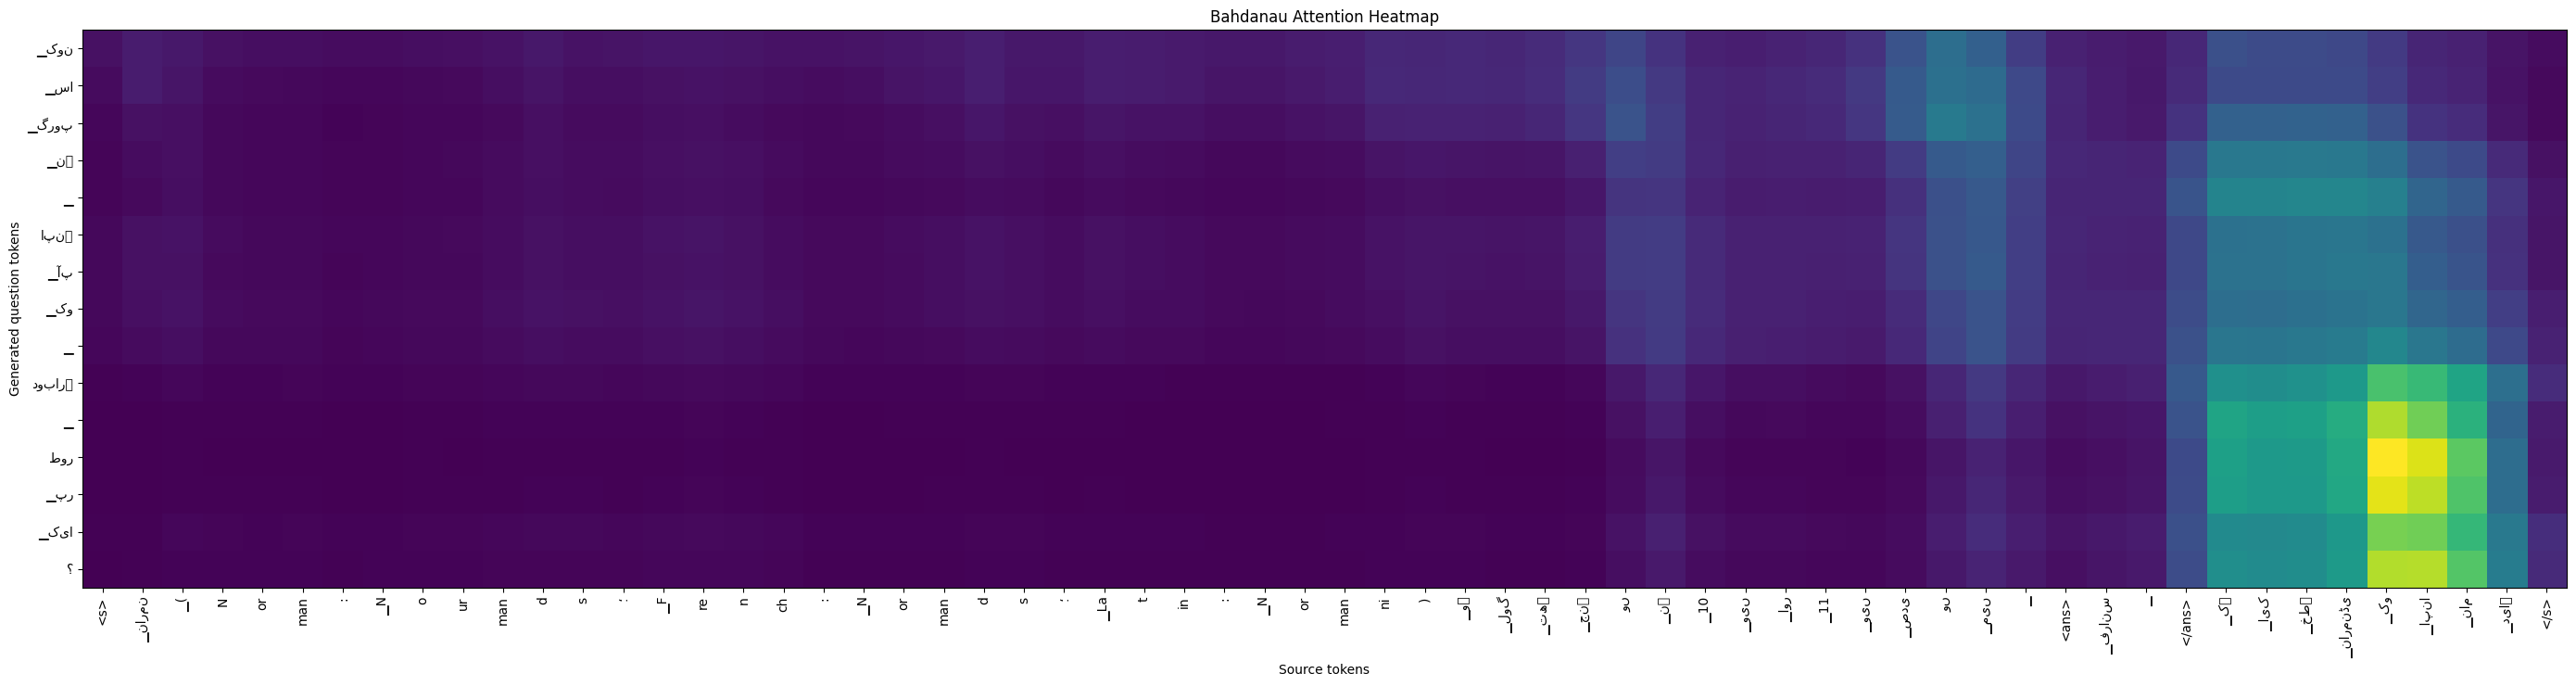

In [102]:
ATTENTION_PATH = (
    RESULTS_DIR /
    "attention_heatmap.png"
)

plot_attention(
    model,
    sp,
    valid_pairs[0][0],
    max_len=30,
    save_path=ATTENTION_PATH
)

In [103]:
final_evaluation = {
    "experiment": "experiment-2",

    "best_epoch": best_epoch,

    "uqa_validation_loss": uqa_valid_loss,

    "uqa_validation_perplexity": uqa_valid_ppl,

    "uqa_validation": {
        "greedy": uqa_greedy_scores,
        "beam_5": uqa_beam_scores
    },

    "wiki_uqa": {
        "num_examples": len(wiki_pairs),
        "greedy": wiki_greedy_scores,
        "beam_5": wiki_beam_scores
    },

    "model": {
        "parameters": count_parameters(model),
        "vocabulary_size": VOCAB_SIZE
    }
}

FINAL_EVALUATION_PATH = (
    RESULTS_DIR /
    "final_evaluation.json"
)

with open(
    FINAL_EVALUATION_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_evaluation,
        f,
        ensure_ascii=False,
        indent=2
    )

print(
    json.dumps(
        final_evaluation,
        ensure_ascii=False,
        indent=2
    )
)

print(
    "\nSaved:",
    FINAL_EVALUATION_PATH
)

{
  "experiment": "experiment-2",
  "best_epoch": 1,
  "uqa_validation_loss": 6.6391770217069395,
  "uqa_validation_perplexity": 764.4655954744359,
  "uqa_validation": {
    "greedy": {
      "BLEU-4": 1.3004837739136892,
      "ROUGE-L": 0.000798881565807869,
      "unk_rate": 0.0
    },
    "beam_5": {
      "BLEU-4": 1.6334353150046321,
      "ROUGE-L": 0.0009986019572598363,
      "unk_rate": 0.0
    }
  },
  "wiki_uqa": {
    "num_examples": 178,
    "greedy": {
      "BLEU-4": 0.60202580838016,
      "ROUGE-L": 0.0,
      "unk_rate": 0.0
    },
    "beam_5": {
      "BLEU-4": 0.56205172947692,
      "ROUGE-L": 0.0,
      "unk_rate": 0.0
    }
  },
  "model": {
    "parameters": 35505984,
    "vocabulary_size": 8000
  }
}

Saved: /kaggle/working/urdu-qgen-seq2seq/results/final_evaluation.json


In [104]:
print("=" * 80)
print("NOTEBOOK 4 — EVALUATION COMPLETE")
print("=" * 80)

print()

print("MODEL")
print("-" * 40)
print("Experiment:", "experiment-2")
print("Best epoch:", best_epoch)
print(
    "Parameters:",
    f"{count_parameters(model):,}"
)

print()

print("UQA VALIDATION")
print("-" * 40)
print(
    f"Loss: {uqa_valid_loss:.4f}"
)
print(
    f"Perplexity: {uqa_valid_ppl:.2f}"
)

print("\nGreedy:")
for k, v in uqa_greedy_scores.items():
    print(f"  {k}: {v:.6f}")

print("\nBeam-5:")
for k, v in uqa_beam_scores.items():
    print(f"  {k}: {v:.6f}")

print()

print("WIKI-UQA")
print("-" * 40)

print(
    "Examples:",
    len(wiki_pairs)
)

print("\nGreedy:")
for k, v in wiki_greedy_scores.items():
    print(f"  {k}: {v:.6f}")

print("\nBeam-5:")
for k, v in wiki_beam_scores.items():
    print(f"  {k}: {v:.6f}")

print()

print("OUTPUT FILES")
print("-" * 40)
print(evaluation_csv)
print(SAMPLES_PATH)
print(ATTENTION_PATH)
print(FINAL_EVALUATION_PATH)

print()
print("Notebook 4 completed.")

NOTEBOOK 4 — EVALUATION COMPLETE

MODEL
----------------------------------------
Experiment: experiment-2
Best epoch: 1
Parameters: 35,505,984

UQA VALIDATION
----------------------------------------
Loss: 6.6392
Perplexity: 764.47

Greedy:
  BLEU-4: 1.300484
  ROUGE-L: 0.000799
  unk_rate: 0.000000

Beam-5:
  BLEU-4: 1.633435
  ROUGE-L: 0.000999
  unk_rate: 0.000000

WIKI-UQA
----------------------------------------
Examples: 178

Greedy:
  BLEU-4: 0.602026
  ROUGE-L: 0.000000
  unk_rate: 0.000000

Beam-5:
  BLEU-4: 0.562052
  ROUGE-L: 0.000000
  unk_rate: 0.000000

OUTPUT FILES
----------------------------------------
/kaggle/working/urdu-qgen-seq2seq/results/evaluation_metrics.csv
/kaggle/working/urdu-qgen-seq2seq/results/samples.tsv
/kaggle/working/urdu-qgen-seq2seq/results/attention_heatmap.png
/kaggle/working/urdu-qgen-seq2seq/results/final_evaluation.json

Notebook 4 completed.


# Task 5 — Streamlit Frontend

This notebook creates the Streamlit frontend for the Urdu Question Generation system.

The application uses the trained Experiment 2 model with:
- SentencePiece tokenizer
- BiLSTM encoder
- Bahdanau attention
- LSTM decoder
- Greedy decoding
- Beam search decoding

In [105]:
from pathlib import Path
import shutil
import os

PROJECT_ROOT = Path("/kaggle/working/urdu-qgen-seq2seq")

FRONTEND_DIR = PROJECT_ROOT / "frontend"
FRONTEND_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Frontend dir :", FRONTEND_DIR)

Project root : /kaggle/working/urdu-qgen-seq2seq
Frontend dir : /kaggle/working/urdu-qgen-seq2seq/frontend


In [106]:
required_files = {
    "Tokenizer": PROJECT_ROOT / "tokenizer" / "ur_sp.model",
    "Tokenizer vocab": PROJECT_ROOT / "tokenizer" / "ur_sp.vocab",
    "Best model": PROJECT_ROOT / "checkpoints" / "experiment-2" / "best_model.pt",
}

for name, path in required_files.items():
    print(f"{name:20s}: {path.exists()} -> {path}")

Tokenizer           : True -> /kaggle/working/urdu-qgen-seq2seq/tokenizer/ur_sp.model
Tokenizer vocab     : True -> /kaggle/working/urdu-qgen-seq2seq/tokenizer/ur_sp.vocab
Best model          : True -> /kaggle/working/urdu-qgen-seq2seq/checkpoints/experiment-2/best_model.pt


In [107]:
# ## Copy deployment files

# The Streamlit app needs the trained checkpoint and SentencePiece tokenizer.

# Copy tokenizer
shutil.copy2(
    PROJECT_ROOT / "tokenizer" / "ur_sp.model",
    FRONTEND_DIR / "ur_sp.model"
)

shutil.copy2(
    PROJECT_ROOT / "tokenizer" / "ur_sp.vocab",
    FRONTEND_DIR / "ur_sp.vocab"
)

# Copy best Experiment 2 checkpoint
shutil.copy2(
    PROJECT_ROOT / "checkpoints" / "experiment-2" / "best_model.pt",
    FRONTEND_DIR / "best_model.pt"
)

print("Frontend deployment files:")
for p in sorted(FRONTEND_DIR.iterdir()):
    print(f"  {p.name} — {p.stat().st_size / (1024**2):.2f} MB")

Frontend deployment files:
  app.py — 0.00 MB
  best_model.pt — 135.45 MB
  ur_sp.model — 0.37 MB
  ur_sp.vocab — 0.15 MB


In [108]:
# ## Create Streamlit application

# The following application is self-contained and reproduces the same model architecture used during training.

app_code = r'''
import streamlit as st
import torch
import torch.nn as nn
import sentencepiece as spm


# =========================================================
# Configuration — must match Experiment 2
# =========================================================

EMB_DIM = 256
HID_DIM = 512
ENC_LAYERS = 2
DEC_LAYERS = 2
DROPOUT = 0.3

PAD_IDX = 0
UNK_IDX = 1
BOS_IDX = 2
EOS_IDX = 3

MAX_TGT_LEN = 30

ANS_OPEN = "<ans>"
ANS_CLOSE = "</ans>"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# =========================================================
# Model definitions
# =========================================================

class Encoder(nn.Module):
    def __init__(
        self,
        input_dim,
        emb_dim,
        hid_dim,
        n_layers,
        dropout
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            input_dim,
            emb_dim,
            padding_idx=PAD_IDX
        )

        self.rnn = nn.LSTM(
            emb_dim,
            hid_dim,
            num_layers=n_layers,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True
        )

        self.fc_hidden = nn.Linear(hid_dim * 2, hid_dim)
        self.fc_cell = nn.Linear(hid_dim * 2, hid_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lengths):

        embedded = self.dropout(
            self.embedding(src)
        )

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            src_lengths.cpu(),
            batch_first=True,
            enforce_sorted=True
        )

        packed_outputs, (hidden, cell) = self.rnn(packed)

        outputs, _ = nn.utils.rnn.pad_packed_sequence(
            packed_outputs,
            batch_first=True
        )

        # hidden:
        # [n_layers * 2, batch, hid_dim]

        hidden = torch.cat(
            (hidden[-2], hidden[-1]),
            dim=1
        )

        cell = torch.cat(
            (cell[-2], cell[-1]),
            dim=1
        )

        hidden = self.fc_hidden(hidden)
        cell = self.fc_cell(cell)

        # Replicate projected state for decoder layers
        hidden = hidden.unsqueeze(0).repeat(
            DEC_LAYERS, 1, 1
        )

        cell = cell.unsqueeze(0).repeat(
            DEC_LAYERS, 1, 1
        )

        return outputs, hidden, cell


class BahdanauAttention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim):
        super().__init__()

        self.attn = nn.Linear(
            enc_hid_dim * 2 + dec_hid_dim,
            dec_hid_dim
        )

        self.v = nn.Linear(
            dec_hid_dim,
            1,
            bias=False
        )

    def forward(self, hidden, encoder_outputs, mask):

        # hidden:
        # [dec_layers, batch, hid_dim]

        hidden_last = hidden[-1]

        src_len = encoder_outputs.size(1)

        hidden_rep = hidden_last.unsqueeze(1).repeat(
            1,
            src_len,
            1
        )

        energy = torch.tanh(
            self.attn(
                torch.cat(
                    (hidden_rep, encoder_outputs),
                    dim=2
                )
            )
        )

        attention = self.v(energy).squeeze(2)

        attention = attention.masked_fill(
            mask == 0,
            -1e10
        )

        return torch.softmax(attention, dim=1)


class Decoder(nn.Module):
    def __init__(
        self,
        output_dim,
        emb_dim,
        hid_dim,
        n_layers,
        dropout
    ):
        super().__init__()

        self.output_dim = output_dim

        self.embedding = nn.Embedding(
            output_dim,
            emb_dim,
            padding_idx=PAD_IDX
        )

        self.attention = BahdanauAttention(
            hid_dim,
            hid_dim
        )

        self.rnn = nn.LSTM(
            emb_dim + hid_dim * 2,
            hid_dim,
            num_layers=n_layers,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True
        )

        self.fc_out = nn.Linear(
            emb_dim + hid_dim * 2 + hid_dim,
            output_dim
        )

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        input_tok,
        hidden,
        cell,
        encoder_outputs,
        mask
    ):

        # input_tok: [batch]

        input_tok = input_tok.unsqueeze(1)

        embedded = self.dropout(
            self.embedding(input_tok)
        )

        a = self.attention(
            hidden,
            encoder_outputs,
            mask
        )

        a = a.unsqueeze(1)

        weighted = torch.bmm(
            a,
            encoder_outputs
        )

        rnn_input = torch.cat(
            (embedded, weighted),
            dim=2
        )

        output, (hidden, cell) = self.rnn(
            rnn_input,
            (hidden, cell)
        )

        output = output.squeeze(1)
        embedded = embedded.squeeze(1)
        weighted = weighted.squeeze(1)

        prediction = self.fc_out(
            torch.cat(
                (output, weighted, embedded),
                dim=1
            )
        )

        return prediction, hidden, cell, a.squeeze(1)


class Seq2Seq(nn.Module):
    def __init__(
        self,
        encoder,
        decoder,
        device
    ):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def create_mask(self, src):
        return (src != PAD_IDX)

    def forward(self, src, src_lengths, trg):

        batch_size = src.size(0)
        trg_len = trg.size(1)

        output_dim = self.decoder.output_dim

        outputs = torch.zeros(
            batch_size,
            trg_len,
            output_dim,
            device=self.device
        )

        encoder_outputs, hidden, cell = self.encoder(
            src,
            src_lengths
        )

        mask = self.create_mask(src)

        input_tok = trg[:, 0]

        for t in range(1, trg_len):

            output, hidden, cell, _ = self.decoder(
                input_tok,
                hidden,
                cell,
                encoder_outputs,
                mask
            )

            outputs[:, t] = output

            input_tok = trg[:, t]

        return outputs


# =========================================================
# Model + tokenizer loading
# =========================================================

@st.cache_resource
def load_model_and_tokenizer():

    tokenizer = spm.SentencePieceProcessor(
        model_file="ur_sp.model"
    )

    vocab_size = tokenizer.get_piece_size()

    encoder = Encoder(
        vocab_size,
        EMB_DIM,
        HID_DIM,
        ENC_LAYERS,
        DROPOUT
    ).to(DEVICE)

    decoder = Decoder(
        vocab_size,
        EMB_DIM,
        HID_DIM,
        DEC_LAYERS,
        DROPOUT
    ).to(DEVICE)

    model = Seq2Seq(
        encoder,
        decoder,
        DEVICE
    ).to(DEVICE)

    checkpoint = torch.load(
        "best_model.pt",
        map_location=DEVICE
    )

    # Support either a raw state_dict or a checkpoint dictionary
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    model.load_state_dict(state_dict)
    model.eval()

    return model, tokenizer


# =========================================================
# Decoding
# =========================================================

def prepare_source(tokenizer, sentence):

    ids = (
        [BOS_IDX]
        + tokenizer.encode(sentence, out_type=int)
        + [EOS_IDX]
    )

    src = torch.tensor(
        [ids],
        dtype=torch.long,
        device=DEVICE
    )

    src_lengths = torch.tensor(
        [len(ids)],
        dtype=torch.long
    )

    return src, src_lengths


@torch.no_grad()
def greedy_decode(
    model,
    tokenizer,
    sentence,
    max_len=MAX_TGT_LEN
):

    src, src_lengths = prepare_source(
        tokenizer,
        sentence
    )

    encoder_outputs, hidden, cell = model.encoder(
        src,
        src_lengths
    )

    mask = model.create_mask(src)

    input_tok = torch.tensor(
        [BOS_IDX],
        dtype=torch.long,
        device=DEVICE
    )

    output_ids = []

    for _ in range(max_len):

        prediction, hidden, cell, _ = model.decoder(
            input_tok,
            hidden,
            cell,
            encoder_outputs,
            mask
        )

        next_tok = prediction.argmax(
            dim=1
        )

        token_id = next_tok.item()

        if token_id == EOS_IDX:
            break

        if token_id not in (
            PAD_IDX,
            BOS_IDX
        ):
            output_ids.append(token_id)

        input_tok = next_tok

    return tokenizer.decode(output_ids)


@torch.no_grad()
def beam_search_decode(
    model,
    tokenizer,
    sentence,
    beam_width=5,
    max_len=MAX_TGT_LEN,
    length_penalty=0.7
):

    src, src_lengths = prepare_source(
        tokenizer,
        sentence
    )

    encoder_outputs, hidden, cell = model.encoder(
        src,
        src_lengths
    )

    mask = model.create_mask(src)

    # tokens, score, hidden, cell, finished
    beams = [
        (
            [BOS_IDX],
            0.0,
            hidden,
            cell,
            False
        )
    ]

    for _ in range(max_len):

        candidates = []

        for tokens, score, h, c, finished in beams:

            if finished:
                candidates.append(
                    (
                        tokens,
                        score,
                        h,
                        c,
                        True
                    )
                )
                continue

            input_tok = torch.tensor(
                [tokens[-1]],
                dtype=torch.long,
                device=DEVICE
            )

            prediction, new_h, new_c, _ = model.decoder(
                input_tok,
                h,
                c,
                encoder_outputs,
                mask
            )

            log_probs = torch.log_softmax(
                prediction,
                dim=1
            ).squeeze(0)

            top_log_probs, top_indices = log_probs.topk(
                beam_width
            )

            for k in range(beam_width):

                token_id = top_indices[k].item()
                token_score = top_log_probs[k].item()

                candidates.append(
                    (
                        tokens + [token_id],
                        score + token_score,
                        new_h,
                        new_c,
                        token_id == EOS_IDX
                    )
                )

        candidates.sort(
            key=lambda x:
                x[1] /
                (len(x[0]) ** length_penalty),
            reverse=True
        )

        beams = candidates[:beam_width]

        if all(
            beam[4]
            for beam in beams
        ):
            break

    best = max(
        beams,
        key=lambda x:
            x[1] /
            (len(x[0]) ** length_penalty)
    )

    token_ids = [
        token_id
        for token_id in best[0]
        if token_id not in (
            BOS_IDX,
            EOS_IDX,
            PAD_IDX
        )
    ]

    return tokenizer.decode(token_ids)


# =========================================================
# Streamlit UI
# =========================================================

st.set_page_config(
    page_title="Urdu Question Generation",
    page_icon="Q",
    layout="centered"
)

st.title(
    "Urdu Question Generation"
)

st.caption(
    "BiLSTM Encoder + Bahdanau Attention + LSTM Decoder"
)

st.markdown(
    """
Generate an Urdu question from a context sentence and an
answer span.

Wrap the answer with `<ans>` and `</ans>`.
"""
)

st.markdown(
    """
**Example**

`دریائے سندھ کی لمبائی <ans> 3,180 کلومیٹر </ans> ہے۔`
"""
)

sentence = st.text_area(
    "Input sentence",
    height=130,
    placeholder=(
        "Enter an Urdu context with the answer marked "
        "using <ans> ... </ans>"
    )
)

beam_width = st.slider(
    "Beam width",
    min_value=2,
    max_value=8,
    value=5
)

if st.button(
    "Generate Question",
    type="primary"
):

    if not sentence.strip():

        st.warning(
            "Please enter an input sentence."
        )

    elif (
        ANS_OPEN not in sentence
        or ANS_CLOSE not in sentence
    ):

        st.error(
            "Please wrap the answer span in "
            "`<ans> ... </ans>`."
        )

    else:

        try:

            model, tokenizer = (
                load_model_and_tokenizer()
            )

            with st.spinner(
                "Generating question..."
            ):

                greedy_question = greedy_decode(
                    model,
                    tokenizer,
                    sentence
                )

                beam_question = beam_search_decode(
                    model,
                    tokenizer,
                    sentence,
                    beam_width=beam_width
                )

            st.subheader("Generated Questions")

            st.write(
                "**Greedy decoding:**"
            )

            st.success(
                greedy_question
                if greedy_question
                else "No question generated."
            )

            st.write(
                "**Beam search:**"
            )

            st.success(
                beam_question
                if beam_question
                else "No question generated."
            )

            with st.expander(
                "Input details"
            ):

                answer_match = (
                    sentence.split(ANS_OPEN, 1)[1]
                    .split(ANS_CLOSE, 1)[0]
                    .strip()
                )

                st.write(
                    "**Answer span:**",
                    answer_match
                )

                st.write(
                    "**Device:**",
                    str(DEVICE)
                )

        except Exception as e:

            st.error(
                f"Generation failed: {e}"
            )
'''

app_path = FRONTEND_DIR / "app.py"
app_path.write_text(app_code, encoding="utf-8")

print(f"Created: {app_path}")
print(f"Size: {app_path.stat().st_size / 1024:.1f} KB")

Created: /kaggle/working/urdu-qgen-seq2seq/frontend/app.py
Size: 14.1 KB


In [109]:
requirements_code = """streamlit
torch
sentencepiece
"""

requirements_path = FRONTEND_DIR / "requirements.txt"
requirements_path.write_text(
    requirements_code,
    encoding="utf-8"
)

print(requirements_path)
print(requirements_path.read_text())

/kaggle/working/urdu-qgen-seq2seq/frontend/requirements.txt
streamlit
torch
sentencepiece



In [110]:
print("Frontend files:")
print()

for path in sorted(FRONTEND_DIR.iterdir()):
    print(
        f"{path.name:20s} "
        f"{path.stat().st_size / (1024**2):8.2f} MB"
    )

Frontend files:

app.py                   0.01 MB
best_model.pt          135.45 MB
requirements.txt         0.00 MB
ur_sp.model              0.37 MB
ur_sp.vocab              0.15 MB


In [111]:
import py_compile

py_compile.compile(
    str(FRONTEND_DIR / "app.py"),
    doraise=True
)

print("app.py syntax check: PASSED")

app.py syntax check: PASSED


In [112]:
import sys

sys.path.insert(0, str(FRONTEND_DIR))

print("Frontend files ready.")
print("Best checkpoint:", (FRONTEND_DIR / "best_model.pt").exists())
print("Tokenizer:", (FRONTEND_DIR / "ur_sp.model").exists())

Frontend files ready.
Best checkpoint: True
Tokenizer: True


In [113]:
# =========================================================
# CELL 12 — Final frontend file verification
# =========================================================

frontend_files = [
    "app.py",
    "requirements.txt",
    "best_model.pt",
    "ur_sp.model",
    "ur_sp.vocab",
]

print("Frontend deployment files:\n")

all_exist = True

for filename in frontend_files:
    path = FRONTEND_DIR / filename
    exists = path.exists()

    print(f"{filename:20s} -> {exists}")

    if not exists:
        all_exist = False

print("\nFrontend package ready:", all_exist)

Frontend deployment files:

app.py               -> True
requirements.txt     -> True
best_model.pt        -> True
ur_sp.model          -> True
ur_sp.vocab          -> True

Frontend package ready: True
